
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h1>Homework, Task 1: Import and explore the data (EDA)</h1>

<p>This homework uses repeat-purchase data from Everything & Then Some. Each row of train.csv is a single purchase, and the target Repeat Purchase 90 Days indicates whether the same customer made another purchase within 90 days (1) or not (0). The overall goal is to predict this target for unseen purchases.</p>

<p>This notebook covers Task 1 only. We import train.csv and the customer table clientes.csv, describe the observations and variables, compute descriptive statistics, and check the data for missing values, implausible values and inconsistencies. We then explore the variables individually, in relation to the target and to each other, and check how stable the data is over time.</p>

<p>The data is left unchanged here. Every issue we find is documented and carried over as an open decision to Task 2, where cleaning and pre-processing take place. test.csv is deliberately not loaded: it is reserved for evaluating the final model, and using it now would let test information influence our decisions (data leakage).</p>

<h2>Contents</h2>

<ol>
  <li><a href="#setup">Setup and import</a></li>
  <li><a href="#vars">Observations and variables</a></li>
  <li><a href="#target">The target</a></li>
  <li><a href="#desc">Descriptive statistics</a></li>
  <li><a href="#quality">Data quality and inconsistencies</a></li>
  <li><a href="#clientes">The customer table clientes.csv</a></li>
  <li><a href="#uni">Univariate distributions</a></li>
  <li><a href="#bi">Bivariate relationships with the target</a></li>
  <li><a href="#multi">Multivariate relationships</a></li>
  <li><a href="#shift">Stability over time within train</a></li>
  <li><a href="#summary">Summary of insights and implications for Task 2</a></li>
</ol>

</div>

<div 
style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">
<a id="setup"></a>
<h2>Setup and Import</h2>
</div>

In [64]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.metrics import roc_auc_score

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


sns.set_theme(style="whitegrid", context="notebook")
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8984"
CLASS_COLORS = {0: BLUE, 1: ORANGE}
DIVERGING = sns.blend_palette(["#1c5cab", "#f0efec", "#d03b3b"], as_cmap=True)
FIGSIZE = (11, 4.5)

TARGET = "repeat_purchase_90d"


LABELS = {
    "Total a Pagar": "Total Payable", "Total Bruto": "Gross Total", "Total Liquido": "Net Total",
    "Total Imp_": "Total Tax", "Total Portes": "Shipping Cost", "Total Desc_ Global": "Global Discount",
    "Total Desc_ Linha": "Line Discount", "Custo": "Cost", "N_ Detalhes": "Number of Lines",
    "invoice_count_current_purchase": "Invoices in Purchase", TARGET: "Repeat Purchase 90 Days",
    "customer_id": "Customer ID", "prior_std_purchase_value": "Prior Std of Purchase Value",
    "prior_std_gap_days": "Prior Std of Gap Days",
}
SMALL_WORDS = {"or", "of", "in", "to"}

def nice(name):
    """English display label without underscores, e.g. payment_type -> Payment Type, spend_30d -> Spend 30 Days."""
    if name in LABELS:
        return LABELS[name]
    words = re.sub(r"(\d+)d\b", r"\1 Days", str(name)).replace("_", " ").split()
    return " ".join(w if w.isupper() or w[0].isdigit() or w in SMALL_WORDS else w.capitalize() for w in words)

In [65]:
DATA_DIR = Path.home() / "Downloads" / "Project" / "data"
if not DATA_DIR.exists():  # fall back to a data folder next to the notebook
    DATA_DIR = Path("data")

train = pd.read_csv(DATA_DIR / "train.csv")
clientes = pd.read_csv(DATA_DIR / "clientes.csv")

pd.DataFrame(
    {name: {"Rows": df.shape[0], "Columns": df.shape[1]}
     for name, df in [("Train (train.csv)", train), ("Customer Table (clientes.csv)", clientes)]}
).T

,Rows,Columns
Train (train.csv),6534,39
Customer Table (clientes.csv),1143,13


In [66]:
print("Customer ID unique in the customer table:", clientes["customer_id"].is_unique)
found = train["customer_id"].drop_duplicates().isin(clientes["customer_id"]).sum()
print(f"Train customers found in the customer table: {found} of {train['customer_id'].nunique()}")

train.head().rename(columns=nice)

Customer ID unique in the customer table: True
Train customers found in the customer table: 610 of 610


,Total Payable,Gross Total,Net Total,Total Tax,Shipping Cost,Global Discount,Line Discount,Cost,Number of Lines,Invoices in Purchase,Repeat Purchase 90 Days,Days Since Previous Purchase,Customer Tenure Days,Prior Purchase Count,Prior Total Spend,Prior Mean Purchase Value,Prior Std of Purchase Value,Prior Min Purchase Value,Prior Max Purchase Value,Prior Mean Gap Days,Prior Std of Gap Days,Purchase Count 30 Days,Spend 30 Days,Purchase Count 90 Days,Spend 90 Days,Purchase Count 180 Days,Spend 180 Days,Purchase Count 365 Days,Spend 365 Days,Customer ID,Payment Type,Salesperson,Commercial Zone,Transport Method,Warehouse,Document Series,Purchase Date,ID,Random Noise
0,558.110,510.900,453.750,104.360,0.000,0.000,57.150,153.100,4.000,1.000,1,79.000,126.000,2.000,858.300,429.150,112.656,349.490,508.810,47.000,NaN,0.000,0.000,1.000,349.490,2.000,858.300,2.000,858.300,660784,Maybe Tomorrow Payment 10,VLOOKUP Master 9,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2024-10-29,10000000,-0.660
1,978.800,830.020,795.770,183.030,0.000,0.000,34.250,472.943,32.000,1.000,1,244.000,616.000,5.000,"6,722.830","1,344.566","1,683.795",84.380,"4,222.150",93.000,117.658,0.000,0.000,0.000,0.000,0.000,0.000,4.000,"2,500.680",189146,Maybe Tomorrow Payment 7,VLOOKUP Master 1,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 36,Final Excel Warehouse 1,Ctrl Z Series 1,2017-07-08,10000001,0.925
2,10.330,12.000,8.400,1.930,0.000,0.000,3.600,6.097,1.000,1.000,1,9.000,610.000,90.000,"17,590.080",195.445,190.390,4.540,"1,002.150",6.753,6.384,2.000,111.270,9.000,"1,928.550",28.000,"5,290.250",49.000,"7,899.800",103940,Maybe Tomorrow Payment 9,VLOOKUP Master 1,Decorative Dashboard Zone 4,NaN,Final Excel Warehouse 1,Ctrl Z Series 3,2019-03-19,10000002,-0.259
3,856.830,696.610,696.610,160.220,0.000,0.000,0.000,408.167,9.000,1.000,0,97.000,97.000,1.000,270.330,270.330,NaN,270.330,270.330,NaN,NaN,0.000,0.000,0.000,0.000,1.000,270.330,1.000,270.330,512927,Maybe Tomorrow Payment 7,VLOOKUP Master 4,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 71,Final Excel Warehouse 1,Ctrl Z Series 3,2018-11-10,10000003,1.448
4,"1,616.100","1,488.850","1,313.900",302.200,0.000,0.000,174.950,485.402,33.000,1.000,1,85.000,"1,575.000",25.000,"12,803.020",512.121,406.697,22.580,"1,736.740",62.083,66.247,0.000,0.000,2.000,184.130,4.000,"2,062.500",4.000,"2,062.500",122356,Maybe Tomorrow Payment 12,NaN,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2021-11-30,10000004,-1.059


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>The train file has 6,534 rows and 39 columns, made up of 37 features, the row key ID and the target. The customer table holds 1,143 customers with 13 columns and joins to train through Customer ID.</p>

</div>

<a id="vars"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>2. Observations and variables</h2>

<h3>2.1 What one row is</h3>

</div>

In [67]:
print(f"ID unique in train: {train['ID'].is_unique}") # True if no ID appears twice

rows_per_customer = train.groupby("customer_id").size()
n_customers = train["customer_id"].nunique()
single_row = (rows_per_customer == 1).sum()
top10_rows = rows_per_customer.nlargest(10).sum()

print(f"train: {len(train):,} rows from {n_customers:,} customers")
print("\nRows per customer:")
print(rows_per_customer.describe().round(1).to_string())
print(f"\ncustomers with exactly one row: {single_row}")
print(f"Top 10 customers hold {top10_rows:,} rows ({top10_rows / len(train):.1%})")
# A random split puts purchases of the same big customer in both training and validation, so the model can recognise the customer and the score looks better than it really is.

dates_train = pd.to_datetime(train["purchase_date"])
print(f"\nPurchase date: {dates_train.min().date()} to {dates_train.max().date()}")

ID unique in train: True
train: 6,534 rows from 610 customers

Rows per customer:
count   610.000
mean     10.700
std      20.000
min       1.000
25%       1.000
50%       4.000
75%      12.000
max     277.000

customers with exactly one row: 157
Top 10 customers hold 1,145 rows (17.5%)

Purchase date: 2015-07-11 to 2025-02-15


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>ID is unique and carries no meaning. The 6,534 rows come from only 610 customers, the median customer has 4 rows, 157 customers have a single row and the 10 largest customers hold 17.5% of all rows. Because rows of the same customer share their history, validation in Task 4 should be grouped by customer or split by time. The data covers almost ten years, from 11 July 2015 to 15 February 2025.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>2.2 Variable dictionary and roles</h3>

<p>The original column names are partly Portuguese and written in snake case, because the data is an invoice export from an ERP system. Every table and plot in this notebook therefore shows readable English labels, while the data keeps its original names so the code can use them. The dictionary below lists both. Each variable is also assigned a role, and this role, not its data type, determines how it is treated in the rest of the notebook.</p>

</div>

In [68]:
INVOICE = ["Total a Pagar", "Total Bruto", "Total Liquido", "Total Imp_", "Total Portes",
           "Total Desc_ Global", "Total Desc_ Linha", "Custo", "N_ Detalhes",
           "invoice_count_current_purchase"]
HISTORY = ["days_since_previous_purchase", "customer_tenure_days", "prior_purchase_count",
           "prior_total_spend", "prior_mean_purchase_value", "prior_std_purchase_value",
           "prior_min_purchase_value", "prior_max_purchase_value", "prior_mean_gap_days",
           "prior_std_gap_days"]
WINDOWS = ["purchase_count_30d", "spend_30d", "purchase_count_90d", "spend_90d",
           "purchase_count_180d", "spend_180d", "purchase_count_365d", "spend_365d"]
CATEGORICAL = ["payment_type", "salesperson", "commercial_zone", "transport_method",
               "warehouse", "document_series"]
IDENTIFIERS = ["ID", "customer_id"]
NUMERIC = INVOICE + HISTORY + WINDOWS

meaning = {
    "Total a Pagar": "amount payable (net + VAT)", "Total Bruto": "gross amount before discounts",
    "Total Liquido": "net amount after discounts, excl. VAT", "Total Imp_": "tax (VAT) amount",
    "Total Portes": "shipping charge", "Total Desc_ Global": "document level discount",
    "Total Desc_ Linha": "sum of line level discounts", "Custo": "cost of goods sold",
    "N_ Detalhes": "number of invoice lines", "invoice_count_current_purchase": "invoices in this purchase",
    "days_since_previous_purchase": "recency, days since the customer's previous purchase",
    "customer_tenure_days": "days since the customer's first purchase",
    "prior_purchase_count": "number of earlier purchases", "prior_total_spend": "total earlier spend",
    "prior_mean_purchase_value": "mean value of earlier purchases",
    "prior_std_purchase_value": "std of earlier purchase values",
    "prior_min_purchase_value": "smallest earlier purchase", "prior_max_purchase_value": "largest earlier purchase",
    "prior_mean_gap_days": "mean days between earlier purchases",
    "prior_std_gap_days": "std of days between earlier purchases",
    "payment_type": "payment terms code", "salesperson": "salesperson code",
    "commercial_zone": "commercial zone code", "transport_method": "delivery method code",
    "warehouse": "warehouse code", "document_series": "invoice document series",
    "purchase_date": "date of the purchase", "ID": "row identifier (submission key)",
    "customer_id": "customer key (joins to the customer table)", "random_noise": "pure noise column",
    TARGET: "1 = customer purchases again within 90 days",
}
for w in [30, 90, 180, 365]:
    meaning[f"purchase_count_{w}d"] = f"purchases in the {w} days before this one"
    meaning[f"spend_{w}d"] = f"spend in the {w} days before this one"

def role(c):
    if c == TARGET: return "target"
    if c in IDENTIFIERS: return "identifier"
    if c in INVOICE: return "current purchase (invoice)"
    if c in HISTORY: return "customer history"
    if c in WINDOWS: return "rolling window"
    if c in CATEGORICAL: return "categorical code"
    if c == "purchase_date": return "date"
    return "noise"

dictionary = pd.DataFrame({
    "Original Name": train.columns,
    "Role": [role(c) for c in train.columns],
    "Meaning": [meaning[c] for c in train.columns],
    "Data Type": train.dtypes.astype(str).values,
    "Unique Values": train.nunique().values,
    "Missing (%)": (100 * train.isna().mean()).round(2).values,
}, index=[nice(c) for c in train.columns]).rename_axis("Label")
dictionary.sort_values("Role")

,Original Name,Role,Meaning,Data Type,Unique Values,Missing (%)
Label,,,,,,
Payment Type,payment_type,categorical code,payment terms code,object,9,3.980
Salesperson,salesperson,categorical code,salesperson code,object,9,3.960
Commercial Zone,commercial_zone,categorical code,commercial zone code,object,5,0.990
Transport Method,transport_method,categorical code,delivery method code,object,80,3.990
Warehouse,warehouse,categorical code,warehouse code,object,2,3.980
Document Series,document_series,categorical code,invoice document series,object,3,0.990
Total Payable,Total a Pagar,current purchase (invoice),amount payable (net + VAT),float64,6122,0.990
Invoices in Purchase,invoice_count_current_purchase,current purchase (invoice),invoices in this purchase,float64,5,0.990
Number of Lines,N_ Detalhes,current purchase (invoice),number of invoice lines,float64,171,0.990


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>The 39 columns form five blocks rather than 39 independent variables. Ten describe the current invoice, ten the customer's earlier purchases, eight the purchase count and spend in the 30, 90, 180 and 365 days before the purchase, six are categorical codes, and the remaining five are ID, Customer ID, Purchase Date, Random Noise and the target. The categorical levels are anonymised names such as "Maybe Tomorrow Payment 7", so their meaning has to come from the data. The numeric columns are stored as decimals only because of the empty rows found in Section 5.1.</p>

</div>

<a id="target"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>3. The target</h2>

</div>

,Rows,Share
Repeat purchase,,
0 = No repeat,"2,880",44.1%
1 = Repeat,"3,654",55.9%


Majority class baseline accuracy: 0.5592


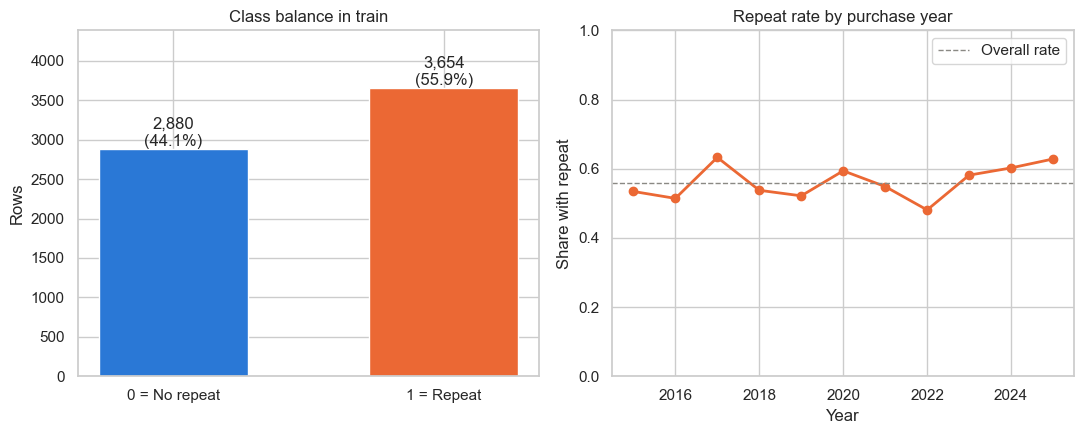

Year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Repeat rate,53.4%,51.4%,63.3%,53.8%,52.2%,59.4%,54.9%,48.1%,58.1%,60.2%,62.8%
Purchases,335,420,670,716,646,670,782,628,767,757,78


In [69]:
balance = train[TARGET].value_counts().sort_index()
display(balance.to_frame("Rows").assign(Share=balance / balance.sum())
        .rename(index={0: "0 = No repeat", 1: "1 = Repeat"})
        .rename_axis("Repeat purchase")
        .style.format({"Rows": "{:,}", "Share": "{:.1%}"}))
print(f"Majority class baseline accuracy: {balance.max() / balance.sum():.4f}")

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
axes[0].bar(["0 = No repeat", "1 = Repeat"], balance.values, color=[BLUE, ORANGE], width=0.55)
for i, v in enumerate(balance.values):
    axes[0].text(i, v, f"{v:,}\n({v / balance.sum():.1%})", ha="center", va="bottom")
axes[0].set(title="Class balance in train", ylabel="Rows", ylim=(0, balance.max() * 1.2))

by_year = train.groupby(dates_train.dt.year)[TARGET].agg(["mean", "size"])
by_year.index = by_year.index.astype(int)
axes[1].plot(by_year.index, by_year["mean"], marker="o", color=ORANGE, lw=2)
axes[1].axhline(train[TARGET].mean(), color=GREY, ls="--", lw=1, label="Overall rate")
axes[1].set(title="Repeat rate by purchase year", ylabel="Share with repeat",
            xlabel="Year", ylim=(0, 1))
axes[1].legend()
plt.tight_layout(); plt.show()

year_table = (by_year.rename(columns={"mean": "Repeat rate", "size": "Purchases"})
                     .rename_axis("Year").T)
year_table.style.format("{:.1%}", subset=pd.IndexSlice["Repeat rate", :]) \
                .format("{:,.0f}", subset=pd.IndexSlice["Purchases", :]) \
                .set_caption("Repeat rate and number of purchases per year")

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>3,654 rows (55.9%) are repeats and 2,880 (44.1%) are not, so always predicting a repeat already reaches an accuracy of 0.559. Task 4 should therefore use a metric that looks at both classes, such as ROC AUC or balanced accuracy, and compare it with this baseline. The yearly repeat rate moves between 0.48 in 2022 and 0.63 in 2017 and 2025 without a trend, and the 2025 value rests on only 78 rows.</p>

</div>

<a id="desc"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>4. Descriptive statistics</h2>

<h3>4.1 Numeric variables</h3>

<p>The standard summary statistics are is extended with the skewness, the share of exact zeros and the ratio of mean to median. These three measures show whether mean and standard deviation are meaningful summaries of a variable at all.</p>

</div>

In [70]:
# Statistics on the rows that carry values: 65 rows are completely empty and would otherwise deflate the share of zeros.
num = train[NUMERIC + ["random_noise"]].dropna(how="all")
desc = num.describe().T
desc["median"] = num.median()
desc["mean/median"] = desc["mean"] / desc["median"].replace(0, np.nan)
desc["skew"] = num.skew()
desc["% zeros"] = 100 * (num == 0).mean()
(desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "mean/median", "skew", "% zeros"]]
 .rename(index=nice, columns={"count": "Count", "mean": "Mean", "std": "Std", "min": "Min", "50%": "Median",
                              "max": "Max", "mean/median": "Mean to Median", "skew": "Skew", "% zeros": "Zeros (%)"}))

,Count,Mean,Std,Min,25%,Median,75%,Max,Mean to Median,Skew,Zeros (%)
Total Payable,"6,469.000",925.556,"1,334.998",0.930,188.920,476.740,"1,087.670","22,297.210",1.941,4.209,0.000
Gross Total,"6,469.000",886.153,"1,327.641",0.830,175.740,445.740,"1,036.700","21,578.280",1.988,4.313,0.000
Net Total,"6,469.000",773.336,"1,136.356",0.760,154.380,389.910,903.370,"18,127.810",1.983,4.152,0.000
Total Tax,"6,469.000",152.220,225.262,0.000,29.930,79.740,184.840,"4,169.400",1.909,4.836,3.293
Shipping Cost,"6,469.000",1.151,5.844,0.000,0.000,0.000,0.000,181.060,NaN,19.549,83.722
Global Discount,"6,469.000",0.350,5.117,0.000,0.000,0.000,0.000,218.490,NaN,27.458,98.300
Line Discount,"6,469.000",112.466,289.986,0.000,0.000,13.130,92.280,"4,103.440",8.566,5.923,37.734
Cost,"6,469.000",328.165,519.507,0.000,49.050,152.540,396.061,"7,427.401",2.151,4.611,7.513
Number of Lines,"6,469.000",21.525,27.713,1.000,4.000,11.000,29.000,423.000,1.957,2.981,0.000
Invoices in Purchase,"6,469.000",1.066,0.311,1.000,1.000,1.000,1.000,5.000,1.066,6.436,0.000


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>Almost every amount column is strongly right skewed, with a skewness between 4 and 6 and a mean about twice the median (Total Payable has a mean of 925.6 and a median of 476.7). Medians describe a typical purchase better, and a log transform is a candidate for Task 2. Global Discount (98.3%), Shipping Cost (83.7%) and Line Discount (37.7%) are mostly zero, and 9.3% of rows are first purchases without any history. Prior Mean Purchase Value and Spend 365 Days contain the value 1,000,000,000 and negative amounts, and two day columns go down to &minus;4. These impossible values push the mean of Prior Mean Purchase Value to 2.8 million against a median of 725 and are examined in Section 5.4.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>4.2 Categorical variables</h3>

</div>

In [71]:
# The 65 empty rows (Section 5.1) are left out so that the missing share counts real gaps only.
filled_cat = train.loc[train["purchase_date"].notna(), CATEGORICAL]
cat_summary = pd.DataFrame({
    "Levels": filled_cat.nunique(),
    "Most Frequent": filled_cat.mode().iloc[0],
    "Share of Most Frequent": filled_cat.apply(lambda s: s.value_counts(normalize=True).iloc[0]),
    "Levels with < 30 Rows": filled_cat.apply(lambda s: (s.value_counts() < 30).sum()),
    "Missing (%)": 100 * filled_cat.isna().mean(),
})
cat_summary.rename(index=nice)

,Levels,Most Frequent,Share of Most Frequent,Levels with < 30 Rows,Missing (%)
Payment Type,9,Maybe Tomorrow Payment 7,0.728,4,3.014
Salesperson,9,VLOOKUP Master 1,0.646,3,2.999
Commercial Zone,5,Decorative Dashboard Zone 4,0.968,2,0.000
Transport Method,80,Maybe Tomorrow Delivery 72,0.178,51,3.030
Warehouse,2,Final Excel Warehouse 1,0.997,1,3.014
Document Series,3,Ctrl Z Series 2,0.423,0,0.000


In [72]:
for col in CATEGORICAL:
    if col == "transport_method":
        continue
    counts = train[col].value_counts(dropna=False)
    counts.index = counts.index.fillna("(Missing)")
    display(counts.to_frame("Rows").assign(Share=counts / counts.sum())
            .rename_axis(nice(col))
            .style.format({"Rows": "{:,}", "Share": "{:.1%}"})
            .set_table_attributes('style="width:100%"'))

,Rows,Share
Payment Type,,
Maybe Tomorrow Payment 7,"4,565",69.9%
Maybe Tomorrow Payment 12,991,15.2%
Maybe Tomorrow Payment 9,502,7.7%
(Missing),260,4.0%
Maybe Tomorrow Payment 10,134,2.1%
Maybe Tomorrow Payment 8,40,0.6%
Maybe Tomorrow Payment 2,21,0.3%
Maybe Tomorrow Payment 4,9,0.1%
Maybe Tomorrow Payment 11,8,0.1%


,Rows,Share
Salesperson,,
VLOOKUP Master 1,"4,054",62.0%
VLOOKUP Master 4,"1,461",22.4%
VLOOKUP Master 9,384,5.9%
(Missing),259,4.0%
VLOOKUP Master 7,201,3.1%
VLOOKUP Master 2,123,1.9%
VLOOKUP Master 3,30,0.5%
VLOOKUP Master 6,12,0.2%
VLOOKUP Master 5,7,0.1%


,Rows,Share
Commercial Zone,,
Decorative Dashboard Zone 4,"6,260",95.8%
Decorative Dashboard Zone 2,151,2.3%
(Missing),65,1.0%
Decorative Dashboard Zone 3,56,0.9%
Decorative Dashboard Zone 6,1,0.0%
Decorative Dashboard Zone 7,1,0.0%


,Rows,Share
Warehouse,,
Final Excel Warehouse 1,"6,253",95.7%
(Missing),260,4.0%
Final Excel Warehouse 3,21,0.3%


,Rows,Share
Document Series,,
Ctrl Z Series 2,"2,738",41.9%
Ctrl Z Series 3,"1,903",29.1%
Ctrl Z Series 1,"1,828",28.0%
(Missing),65,1.0%


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>Most categorical variables are dominated by one level and have a long tail of rare ones. Commercial Zone (96.8% Zone 4) and Warehouse (99.7% Warehouse 1) are almost constant and can carry little information. Transport Method has 80 levels, 51 of them with fewer than 30 rows, so rare levels need to be grouped before encoding in Task 2. Payment Type and Salesperson each have 9 levels, Document Series is balanced across three series but turns out to be a proxy for time in Section 10, and four of the six variables miss about 3% of their values.</p>

</div>

<a id="quality"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>5. Data quality and inconsistencies</h2>

<p>Each check below follows from what a column <i>means</i>: the rule is stated first and then measured on the data.</p>

<h3>5.1 Empty rows</h3>

</div>

In [73]:
feature_cols = [c for c in train.columns if c not in IDENTIFIERS + [TARGET]]
empty_rows = train[feature_cols].isna().all(axis=1)
print(f"Rows with every feature missing: {empty_rows.sum()} "
      f"({empty_rows.mean():.2%}); repeat rate among them: {train.loc[empty_rows, TARGET].mean():.3f}")
train.loc[empty_rows].head().rename(columns=nice)

Rows with every feature missing: 65 (0.99%); repeat rate among them: 0.508


,Total Payable,Gross Total,Net Total,Total Tax,Shipping Cost,Global Discount,Line Discount,Cost,Number of Lines,Invoices in Purchase,Repeat Purchase 90 Days,Days Since Previous Purchase,Customer Tenure Days,Prior Purchase Count,Prior Total Spend,Prior Mean Purchase Value,Prior Std of Purchase Value,Prior Min Purchase Value,Prior Max Purchase Value,Prior Mean Gap Days,Prior Std of Gap Days,Purchase Count 30 Days,Spend 30 Days,Purchase Count 90 Days,Spend 90 Days,Purchase Count 180 Days,Spend 180 Days,Purchase Count 365 Days,Spend 365 Days,Customer ID,Payment Type,Salesperson,Commercial Zone,Transport Method,Warehouse,Document Series,Purchase Date,ID,Random Noise
393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,755628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000457,NaN
484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,755628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000560,NaN
582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,427118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000678,NaN
583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,508217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000679,NaN
748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,427118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000870,NaN


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>65 rows (0.99%) are completely empty apart from ID, Customer ID and the target, not even the purchase date is filled. Their repeat rate of 0.508 is close to the overall rate, so they carry no usable information and are candidates for removal in Task 2. From Section 5.3 on they are excluded from all statistics.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>5.2 Duplicates</h3>

</div>

In [74]:
print("Exact duplicates (all columns):", train.duplicated().sum())
dup_mask = train.drop(columns="ID").duplicated(keep=False)
print("Duplicates ignoring ID:", train.drop(columns="ID").duplicated().sum(),
      f" rows involved: {dup_mask.sum()}, of which empty rows: {(dup_mask & empty_rows).sum()}, "
      f"customers involved: {train.loc[dup_mask, 'customer_id'].nunique()}")
non_empty = train.loc[~empty_rows]
print("Duplicates ignoring ID, rows with data only:", non_empty.drop(columns="ID").duplicated().sum())
print("Same customer on the same date twice:",
      non_empty.duplicated(subset=["customer_id", "purchase_date"]).sum())

Exact duplicates (all columns): 0
Duplicates ignoring ID: 10  rows involved: 16, of which empty rows: 16, customers involved: 6
Duplicates ignoring ID, rows with data only: 0
Same customer on the same date twice: 0


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>There are no duplicated purchases. The 10 duplicates that appear when ID is ignored are all empty rows of the same 6 customers, which look identical because they share customer and target. No customer has two purchases on the same date.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>5.3 Missing values</h3>

<p>From here on the 65 empty rows are excluded from the statistics (stored as tr below). This way the remaining pattern of missing values is visible on its own and is not dominated by rows that are missing everything.</p>

</div>

In [75]:
tr = train.loc[~empty_rows].copy()
tr["purchase_date"] = pd.to_datetime(tr["purchase_date"])

missing = pd.DataFrame({
    "Missing (All Rows)": train.isna().sum(),
    "Missing (Rows with Data)": tr.isna().sum(),
    "Missing % (Rows with Data)": (100 * tr.isna().mean()).round(2),
})
missing = missing[missing["Missing (All Rows)"] > 0].sort_values("Missing (Rows with Data)", ascending=False)
missing.rename(index=nice)

,Missing (All Rows),Missing (Rows with Data),Missing % (Rows with Data)
Prior Std of Gap Days,1478,1413,21.840
Prior Mean Gap Days,1308,1243,19.210
Prior Std of Purchase Value,1113,1048,16.200
Prior Mean Purchase Value,862,797,12.320
Days Since Previous Purchase,861,796,12.300
Prior Min Purchase Value,668,603,9.320
Prior Max Purchase Value,668,603,9.320
Transport Method,261,196,3.030
Payment Type,260,195,3.010
Spend 365 Days,260,195,3.010


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p>Many missing history values are expected, not errors. On a customer's <b>first purchase</b> there is no earlier purchase, so there are no days since the last one. A gap between purchases or a standard deviation needs <b>at least two earlier purchases</b>. The cross-tab below shows how many missing values are explained this way and how many are not.</p>

</div>

In [76]:
prior_bucket = tr["prior_purchase_count"].clip(upper=3).map({0: "0", 1: "1", 2: "2", 3: "3+"})
history_cols = ["days_since_previous_purchase", "prior_mean_purchase_value",
                "prior_min_purchase_value", "prior_std_purchase_value",
                "prior_mean_gap_days", "prior_std_gap_days", "spend_365d"]
history_labels = [nice(c) for c in history_cols]

structural = pd.DataFrame({nice(col): tr[col].isna().groupby(prior_bucket).mean()
                           for col in history_cols}).T
structural.columns.name = "Earlier Purchases"
structural.loc["Rows in Group"] = prior_bucket.value_counts().sort_index()

display(structural.style
        .format("{:.1%}", subset=pd.IndexSlice[history_labels, :])
        .format("{:,.0f}", subset=pd.IndexSlice[["Rows in Group"], :])
        .background_gradient(cmap="Blues", vmin=0, vmax=1, subset=pd.IndexSlice[history_labels, :])
        .set_caption("Share of missing values by number of earlier purchases")
        .set_table_attributes('style="width:100%"'))

Earlier Purchases,0,1,2,3+
Days Since Previous Purchase,100.0%,4.3%,5.5%,3.0%
Prior Mean Purchase Value,100.0%,4.5%,3.0%,3.2%
Prior Min Purchase Value,100.0%,0.0%,0.0%,0.0%
Prior Std of Purchase Value,100.0%,100.0%,0.0%,0.0%
Prior Mean Gap Days,100.0%,100.0%,5.8%,3.4%
Prior Std of Gap Days,100.0%,100.0%,100.0%,0.0%
Spend 365 Days,3.0%,4.3%,4.1%,2.8%
Rows in Group,603,445,365,"5,056"


In [77]:
# Does missingness carry information about the target?
flags = {
    "Recency missing": tr["days_since_previous_purchase"].isna(),
    "First purchase (no earlier purchases)": tr["prior_purchase_count"].eq(0),
    "Recency missing although earlier purchases exist": tr["days_since_previous_purchase"].isna() & tr["prior_purchase_count"].ge(1),
    "Payment Type missing": tr["payment_type"].isna(),
    "Salesperson missing": tr["salesperson"].isna(),
    "Transport Method missing": tr["transport_method"].isna(),
    "Warehouse missing": tr["warehouse"].isna(),
    "Spend 365 Days missing": tr["spend_365d"].isna(),
}
miss_info = pd.DataFrame({
    "Rows Flagged": {k: v.sum() for k, v in flags.items()},
    "Repeat Rate if Flagged": {k: tr.loc[v, TARGET].mean() for k, v in flags.items()},
    "Repeat Rate Otherwise": {k: tr.loc[~v, TARGET].mean() for k, v in flags.items()},
})
miss_info["Difference"] = miss_info["Repeat Rate if Flagged"] - miss_info["Repeat Rate Otherwise"]

display(miss_info.rename_axis("Condition").style
        .format({"Rows Flagged": "{:,}", "Repeat Rate if Flagged": "{:.1%}",
                 "Repeat Rate Otherwise": "{:.1%}", "Difference": "{:+.1%}"})
        .background_gradient(cmap="RdBu", vmin=-0.3, vmax=0.3, subset=["Difference"])
        .set_caption("Repeat rate with and without each missing value condition")
        .set_table_attributes('style="width:100%"'))

,Rows Flagged,Repeat Rate if Flagged,Repeat Rate Otherwise,Difference
Condition,,,,
Recency missing,796,39.1%,58.3%,-19.3%
First purchase (no earlier purchases),603,33.3%,58.3%,-25.0%
Recency missing although earlier purchases exist,193,57.0%,55.9%,+1.1%
Payment Type missing,195,56.4%,56.0%,+0.4%
Salesperson missing,194,59.8%,55.9%,+3.9%
Transport Method missing,196,55.1%,56.0%,-0.9%
Warehouse missing,195,63.6%,55.7%,+7.9%
Spend 365 Days missing,195,56.4%,56.0%,+0.4%


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>Most missing values are structural. All 603 first purchases lack every history statistic, the 445 rows with one earlier purchase have no standard deviation and no gap, and the 365 rows with two have no gap standard deviation. These values are not defined rather than unknown, so an indicator plus a neutral fill fits better than median imputation. Beyond this pattern about 195 values each are missing without a reason in Days Since Previous Purchase, Prior Mean Purchase Value, Prior Mean Gap Days, Spend 365 Days and four categorical variables, and Spend 365 Days is even missing on first purchases where its true value is 0. Only the structural part is linked to the target. A missing recency has a repeat rate of 0.391 against 0.583, which is the first purchase effect (0.333), while the other gaps lie between 0.55 and 0.60 like the complete rows. Only a missing Warehouse is somewhat higher at 0.64 on 195 rows. Simple imputation fitted on train is therefore defensible for these gaps.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>5.4 Impossible values and placeholder codes</h3>

<p>Each column has a valid range: amounts, counts and durations must be ≥ 0, and a mean must lie between the minimum and the maximum. Values outside this range are not extreme values, they are not valid values at all.</p>

</div>

In [78]:
checks = ["prior_mean_purchase_value", "spend_365d", "days_since_previous_purchase", "prior_mean_gap_days"]
rows = []
for col in checks:
    s = tr[col]
    rows.append({"Column": nice(col), "Max": s.max(), "Values ≥ 1e8": (s >= 1e8).sum(),
                 "Negative Values": (s < 0).sum(),
                 "Distinct Negative Values": sorted(s[s < 0].round(2).unique())[:5]})
pd.DataFrame(rows).set_index("Column")

,Max,Values ≥ 1e8,Negative Values,Distinct Negative Values
Column,,,,
Prior Mean Purchase Value,"1,000,000,000.000",16,16,"[-2478.66, -885.1, -883.51, -779.03, -757.48]"
Spend 365 Days,"1,000,000,000.000",15,15,"[-159115.18, -14740.29, -12638.05, -6795.47, -..."
Days Since Previous Purchase,"3,199.000",0,16,[-4.0]
Prior Mean Gap Days,"3,199.000",0,16,[-4.0]


In [79]:
# Are the placeholder codes concentrated on particular rows?
sentinel = (tr["prior_mean_purchase_value"] >= 1e8) | (tr["spend_365d"] >= 1e8)
negative = (tr["prior_mean_purchase_value"] < 0) | (tr["spend_365d"] < 0)
neg_days = (tr["days_since_previous_purchase"] < 0) | (tr["prior_mean_gap_days"] < 0)
print(f"Rows with 1e9 code: {sentinel.sum()}, with a negative amount: {negative.sum()}, "
      f"with negative days: {neg_days.sum()}; rows with any of these: {(sentinel | negative | neg_days).sum()} "
      f"({(sentinel | negative | neg_days).mean():.1%})")
print("Rows where both day columns are negative together:",
      ((tr["days_since_previous_purchase"] < 0) & (tr["prior_mean_gap_days"] < 0)).sum())

Rows with 1e9 code: 31, with a negative amount: 31, with negative days: 32; rows with any of these: 94 (1.5%)
Rows where both day columns are negative together: 0


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>94 rows (1.5%) contain one of three kinds of impossible values. Prior Mean Purchase Value and Spend 365 Days hold the round placeholder 1e9 on 16 and 15 rows and negative amounts on another 16 and 15 rows. The negative means are flipped signs, because all 16 equal exactly minus Prior Total Spend divided by Prior Purchase Count (Section 5.5). Days Since Previous Purchase and Prior Mean Gap Days are exactly &minus;4 on 16 rows each and never on the same row, which again points to a code. These are invalid entries rather than outliers, so Task 2 should set them to missing and recompute or impute them in a reproducible step that can later be applied unchanged to new data.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>5.5 Internal consistency rules</h3>

<p>Some columns in the invoice block and in the history block can be calculated from other columns. Checking these relationships shows (a) which columns are redundant and (b) which rows break a rule.</p>

</div>

In [80]:
close = lambda a, b: np.isclose(a, b, atol=0.02)
# Use the sentinel-free values for the history rules, so one bad code is not counted twice.
h = tr.copy()
for col in ["prior_mean_purchase_value", "spend_365d"]:
    h.loc[(h[col] >= 1e8) | (h[col] < 0), col] = np.nan

rules = {
    "Total Payable = Net Total + Total Tax": close(tr["Total a Pagar"], tr["Total Liquido"] + tr["Total Imp_"]),
    "Total Payable = Net Total + Total Tax + Shipping Cost": close(tr["Total a Pagar"], tr["Total Liquido"] + tr["Total Imp_"] + tr["Total Portes"]),
    "Net Total = Gross Total − Line Discount − Global Discount": close(tr["Total Liquido"], tr["Total Bruto"] - tr["Total Desc_ Linha"] - tr["Total Desc_ Global"]),
    "Cost ≤ Net Total (no sale below cost)": tr["Custo"] <= tr["Total Liquido"],
    "Cost > 0": tr["Custo"] > 0,
    "Purchase Count 30 ≤ 90 ≤ 180 ≤ 365 Days": (tr["purchase_count_30d"] <= tr["purchase_count_90d"]) & (tr["purchase_count_90d"] <= tr["purchase_count_180d"]) & (tr["purchase_count_180d"] <= tr["purchase_count_365d"]),
    "Purchase Count 365 Days ≤ Prior Purchase Count": tr["purchase_count_365d"] <= tr["prior_purchase_count"],
    "Spend 30 ≤ 90 ≤ 180 Days": (tr["spend_30d"] <= tr["spend_90d"] + 0.01) & (tr["spend_90d"] <= tr["spend_180d"] + 0.01),
    "Spend 180 Days ≤ Spend 365 Days (valid values)": (h["spend_180d"] <= h["spend_365d"] + 0.01) | h["spend_365d"].isna(),
    "Prior Max Purchase Value ≤ Prior Total Spend": (tr["prior_max_purchase_value"] <= tr["prior_total_spend"] + 0.01) | tr["prior_max_purchase_value"].isna(),
    "Spend 365 Days ≤ Prior Total Spend (valid values)": (h["spend_365d"] <= h["prior_total_spend"] + 0.01) | h["spend_365d"].isna(),
    "Prior Min ≤ Prior Mean ≤ Prior Max (valid mean)": ((h["prior_min_purchase_value"] <= h["prior_mean_purchase_value"] + 0.01) & (h["prior_mean_purchase_value"] <= h["prior_max_purchase_value"] + 0.01)) | h["prior_mean_purchase_value"].isna(),
    "Prior Total Spend = Prior Mean × Prior Count (valid mean)": close(h["prior_total_spend"], h["prior_mean_purchase_value"] * h["prior_purchase_count"]) | h["prior_mean_purchase_value"].isna(),
    "Days Since Previous Purchase ≤ Customer Tenure Days": (tr["days_since_previous_purchase"] <= tr["customer_tenure_days"]) | tr["days_since_previous_purchase"].isna(),
}
pd.DataFrame({"Rows Satisfying": {k: int(v.sum()) for k, v in rules.items()},
              "Rows Violating": {k: int((~v).sum()) for k, v in rules.items()},
              "Satisfying (%)": {k: round(100 * v.mean(), 2) for k, v in rules.items()}}).rename_axis("Rule")

,Rows Satisfying,Rows Violating,Satisfying (%)
Rule,,,
Total Payable = Net Total + Total Tax,6469,0,100.000
Total Payable = Net Total + Total Tax + Shipping Cost,5416,1053,83.720
Net Total = Gross Total − Line Discount − Global Discount,6469,0,100.000
Cost ≤ Net Total (no sale below cost),6430,39,99.400
Cost > 0,5983,486,92.490
Purchase Count 30 ≤ 90 ≤ 180 ≤ 365 Days,6469,0,100.000
Purchase Count 365 Days ≤ Prior Purchase Count,6469,0,100.000
Spend 30 ≤ 90 ≤ 180 Days,6469,0,100.000
Spend 180 Days ≤ Spend 365 Days (valid values),6469,0,100.000


In [81]:
ship = tr["Total Portes"] > 0
bad_mean = ~rules["Prior Min ≤ Prior Mean ≤ Prior Max (valid mean)"]
bad_max = ~rules["Prior Max Purchase Value ≤ Prior Total Spend"]
neg_mean = tr["prior_mean_purchase_value"] < 0
implied_mean = tr["prior_total_spend"] / tr["prior_purchase_count"]

rows = [
    ("Invoices with a shipping charge", f"{ship.sum():,}",
     "Rows where Shipping Cost was charged"),
    ("…of which Total Payable = Net Total + Total Tax still holds", f"{rules['Total Payable = Net Total + Total Tax'][ship].mean():.0%}",
     "Shipping is already included in the net amount, not added on top"),
    ("Sales below cost", f"{(tr['Custo'] > tr['Total Liquido']).sum():,}",
     "Possible (promotions), but worth flagging"),
    ("Sales with zero cost", f"{(tr['Custo'] == 0).sum():,} ({(tr['Custo'] == 0).mean():.1%})",
     "A margin feature would be unreliable here"),
    ("Mean purchase value outside [min, max]", f"{bad_mean.sum():,}",
     "Impossible, a mean must lie between min and max"),
    ("…of which mean ≠ total / count", f"{(bad_mean & ~rules['Prior Total Spend = Prior Mean × Prior Count (valid mean)']).sum():,}",
     "Confirms the mean column itself is corrupted"),
    ("Max purchase larger than total earlier spend", f"{bad_max.sum():,}",
     "Impossible, one purchase cannot exceed the sum of all"),
    ("Overlap of the two groups above", f"{(bad_mean & bad_max).sum():,}",
     "0 means two separate errors in different rows"),
    ("Negative mean purchase values", f"{neg_mean.sum():,}",
     "Impossible, amounts cannot be negative"),
    ("…of which exactly −(total / count)",
     f"{np.isclose(-tr.loc[neg_mean, 'prior_mean_purchase_value'], implied_mean[neg_mean]).sum():,}",
     "Only the sign is wrong, so the true value can be restored"),
]
display(pd.DataFrame(rows, columns=["Check", "Result", "What It Means"])
        .style.hide(axis="index")
        .set_properties(subset=["Result"], **{"text-align": "center", "font-weight": "bold"})
        .set_caption("Follow-up checks on the consistency rules")
        .set_table_attributes('style="width:100%"'))

# Tax rate of each invoice (Total Tax / Net Total), rounded to whole percent
tax_rate = (tr["Total Imp_"] / tr["Total Liquido"]).round(2)
display(tax_rate.value_counts(normalize=True).head(6).rename("Share of Rows").rename_axis("Tax Rate")
        .to_frame().style.format({"Share of Rows": "{:.1%}"}).format_index("{:.0%}")
        .set_caption("Most frequent tax rates (Total Tax / Net Total)"))

Check,Result,What It Means
Invoices with a shipping charge,"1,053",Rows where Shipping Cost was charged
…of which Total Payable = Net Total + Total Tax still holds,100%,"Shipping is already included in the net amount, not added on top"
Sales below cost,39,"Possible (promotions), but worth flagging"
Sales with zero cost,486 (7.5%),A margin feature would be unreliable here
"Mean purchase value outside [min, max]",45,"Impossible, a mean must lie between min and max"
…of which mean ≠ total / count,45,Confirms the mean column itself is corrupted
Max purchase larger than total earlier spend,45,"Impossible, one purchase cannot exceed the sum of all"
Overlap of the two groups above,0,0 means two separate errors in different rows
Negative mean purchase values,16,"Impossible, amounts cannot be negative"
…of which exactly −(total / count),16,"Only the sign is wrong, so the true value can be restored"


,Share of Rows
Tax Rate,
23%,87.2%
13%,3.4%
0%,3.3%
22%,1.8%
6%,0.9%
21%,0.8%


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>The invoice amounts follow exact accounting rules. Total Payable always equals Net Total plus Total Tax, and Net Total always equals Gross Total minus both discounts, so two of the amount columns are redundant and perfectly collinear. Shipping is already included in Net Total, which is why adding Shipping Cost again breaks the rule on exactly the 1,053 rows with a shipping charge. The tax rate is 23% on 87% of rows, followed by 13%, 0%, 22% and 6%, which matches Portuguese VAT. There are 39 sales below cost and 486 rows (7.5%) with zero cost, so a margin feature would be unreliable. The rolling windows are fully consistent. Three history columns are corrupted on separate rows, Prior Mean Purchase Value on 45 rows where it can be recomputed as total divided by count, Prior Max Purchase Value on 45 other rows and Spend 365 Days on 39 rows. The last two cannot be reconstructed and should be set to missing and imputed in Task 2.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>5.6 Identifier-like and uninformative columns</h3>

</div>

In [82]:
for col in ["ID", "customer_id", "random_noise"]:
    print(f"{nice(col):14s} AUC vs target: {roc_auc_score(tr[TARGET], tr[col]):.3f}")
print(f"\nCorrelation of ID with purchase date order: "
      f"{tr['ID'].corr(tr['purchase_date'].rank(), method='spearman'):.3f}")
print(f"Random Noise: mean {tr['random_noise'].mean():.3f}, std {tr['random_noise'].std():.3f} "
      f"(a standard normal), Mann-Whitney p vs target = "
      f"{mannwhitneyu(tr.loc[tr[TARGET] == 1, 'random_noise'], tr.loc[tr[TARGET] == 0, 'random_noise']).pvalue:.3f}")

ID             AUC vs target: 0.507
Customer ID    AUC vs target: 0.433
Random Noise   AUC vs target: 0.495

Correlation of ID with purchase date order: 0.011
Random Noise: mean -0.022, std 1.001 (a standard normal), Mann-Whitney p vs target = 0.510


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>ID is a pure row key with an AUC of 0.507 and no relation to the purchase date (&rho; = 0.011), so it is kept only for the submission file. Random Noise has an AUC of 0.495 and no significant difference between the classes (p = 0.51), which makes it a useful sanity check for feature selection. Customer ID shows an AUC of 0.433, but the number is an arbitrary code and the apparent signal comes from customers with many rows (Section 9.3), so it is used only for the join and for grouping the validation folds.</p>

</div>

<a id="clientes"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>6. The customer table clientes.csv</h2>

</div>

In [83]:
print(f"{clientes.shape[0]:,} customers, Customer ID unique: {clientes['customer_id'].is_unique}")
print(f"Train customers found in the customer table: "
      f"{train['customer_id'].drop_duplicates().isin(clientes['customer_id']).mean():.1%} "
      f"(all {train['customer_id'].nunique()} train customers; the table holds {len(clientes):,})")
pd.DataFrame({"Unique Values": clientes.nunique(), "Missing (%)": (100 * clientes.isna().mean()).round(1),
              "Example": clientes.iloc[0]}).rename(index=nice)

1,143 customers, Customer ID unique: True
Train customers found in the customer table: 100.0% (all 610 train customers; the table holds 1,143)


,Unique Values,Missing (%),Example
Customer ID,1143,0.000,842570
Country or Region,11,0.000,Country CT11: Land of The Final Version
Commercial Region,37,10.000,Region RG37: We Will See Later
Island,10,50.600,NaN
Municipality,183,13.900,NaN
City,417,47.800,City CY417: Missing Cell Port
Postal Area,271,6.200,NaN
Postal Code,828,14.900,Postal code PC828: #REF! Delivery Route
Street,511,52.300,NaN
Address,1120,0.500,Address AD1120: Cell Without a Home


In [84]:
cl = tr.merge(clientes, on="customer_id", how="left", validate="many_to_one")
first_purchase_year = (cl["purchase_date"] - pd.to_timedelta(cl["customer_tenure_days"], unit="D")).dt.year
gap = first_purchase_year - cl["customer_since_year"]
since = clientes["customer_since_year"].value_counts().sort_index()
display(gap.value_counts().sort_index().rename("Rows")
        .rename_axis("First Purchase Year minus Customer Since Year").to_frame().T)
display(since.rename("Customers").to_frame()
        .assign(Share=since / since.sum()).rename_axis("Customer Since Year").T
        .style.format("{:,.0f}", subset=pd.IndexSlice["Customers", :])
        .format("{:.1%}", subset=pd.IndexSlice["Share", :]))

First Purchase Year minus Customer Since Year,0,1,2,3,4,5,6,7,8,9
Rows,4452,1347,236,276,57,51,24,24,1,1


Customer Since Year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Customers,664,53,82,61,47,50,52,43,29,31,18,13
Share,58.1%,4.6%,7.2%,5.3%,4.1%,4.4%,4.5%,3.8%,2.5%,2.7%,1.6%,1.1%


In [85]:
def rate_table(frame, col, min_rows=30):
    t = frame.groupby(frame[col].fillna("(missing)"))[TARGET].agg(["mean", "size"])
    return t[t["size"] >= min_rows].sort_values("mean")

def show_rates(t, label):
    """Repeat rate table with readable headers."""
    return t.rename(columns={"mean": "Repeat Rate", "size": "Rows"}).rename_axis(label)

cl["island_known"] = cl["island"].notna()
display(show_rates(rate_table(cl, "customer_since_year", 20), "Customer Since Year"))
display(show_rates(rate_table(cl, "country_or_region", 1), "Country or Region"))
display(show_rates(rate_table(cl, "island_known"), "Island Known"))

,Repeat Rate,Rows
Customer Since Year,,
2022,0.252,107
2024,0.308,26
2018,0.346,462
2021,0.367,207
2019,0.433,275
2020,0.493,272
2016,0.568,600
2015,0.596,3532
2023,0.602,108


,Repeat Rate,Rows
Country or Region,,
Country CT4: Land of The Final Version,0.000,1
Country CT8: Land of The Final Version,0.000,1
Country CT9: Land of The Final Version,0.000,1
Country CT7: Land of The Final Version,0.375,8
Country CT5: Land of The Final Version,0.392,194
Country CT6: Land of The Final Version,0.500,8
Country CT10: Land of The Final Version,0.566,6256


,Repeat Rate,Rows
Island Known,,
True,0.518,4280
False,0.641,2189


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>The customer table joins perfectly, since all 610 train customers are found and Customer ID is unique, but it adds little beyond train. Customer Type is completely empty, Company Name and Address are unique per customer, Street, Island and City are about half empty, and Postal Code, City and Municipality are far too detailed for 610 customers. Customer Since Year is never later than the first purchase implied by Customer Tenure Days and matches it on 69% of rows. 58% of the 1,143 customers in the table carry the value 2015, the first year of the data, which most likely means 2015 or earlier, so tenure is the more precise measure. Worth testing in Task 2 are Country or Region (repeat rate 0.566 for CT10 against 0.392 for CT5 with 194 rows), whether Island is known (0.518 if known, 0.641 if not) and Commercial Region with rare levels grouped.</p>

</div>

<a id="uni"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>7. Univariate distributions</h2>

<p>Amounts and counts are strongly right-skewed (Section 4), so they are plotted on a log<sub>10</sub>(1 + x) axis; on a linear scale almost all values would fall into a single bar near zero. Placeholder codes are removed for plotting only; the data itself is not changed.</p>

</div>

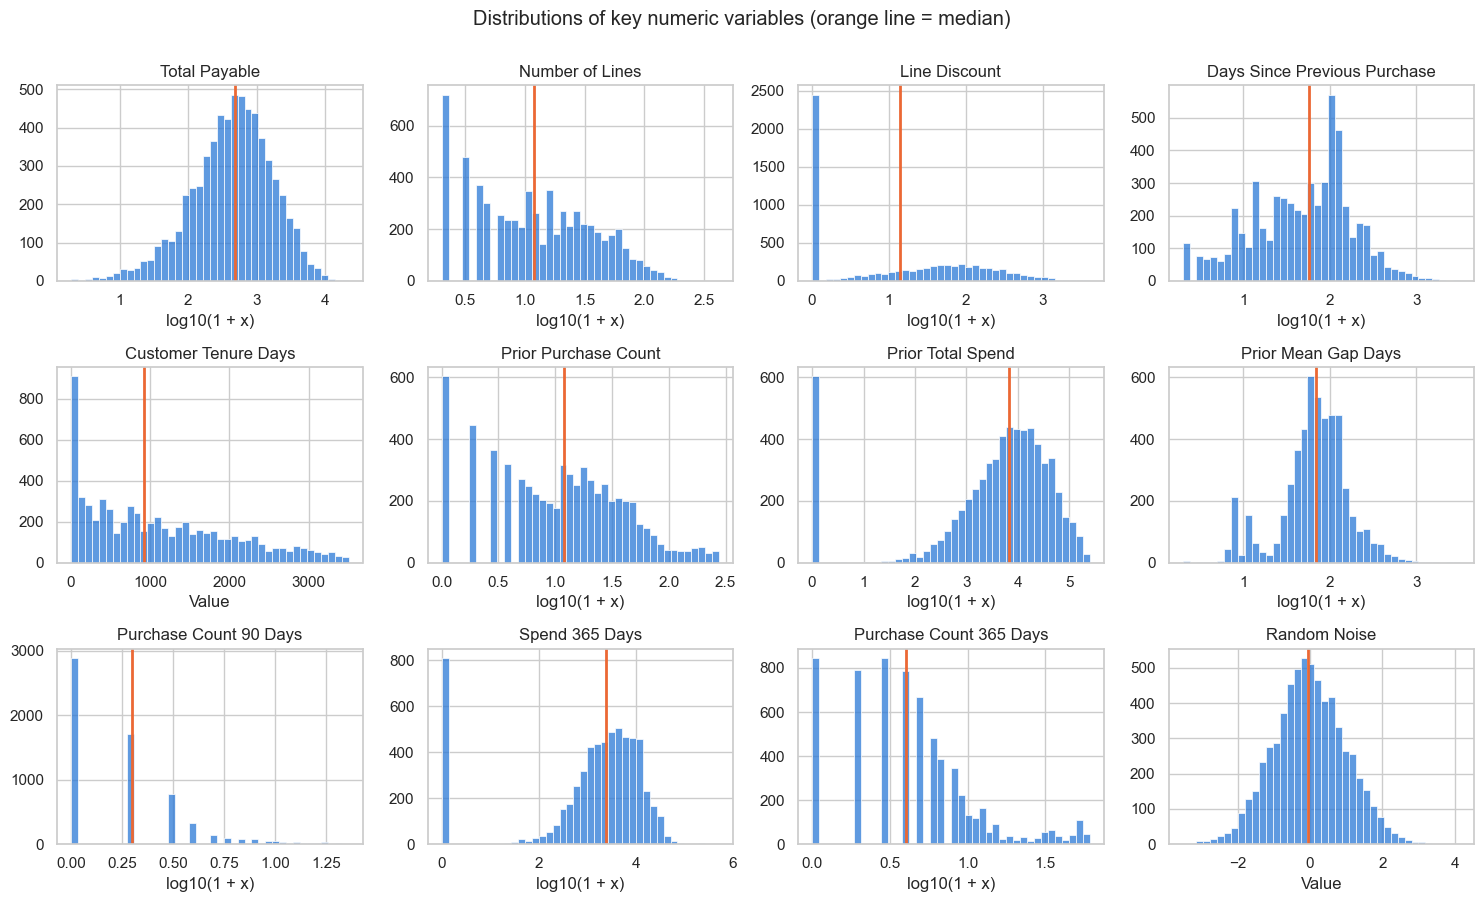

In [86]:
plot_cols = ["Total a Pagar", "N_ Detalhes", "Total Desc_ Linha", "days_since_previous_purchase",
             "customer_tenure_days", "prior_purchase_count", "prior_total_spend",
             "prior_mean_gap_days", "purchase_count_90d", "spend_365d", "purchase_count_365d", "random_noise"]
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for ax, col in zip(axes.ravel(), plot_cols):
    s = h[col].dropna()
    s = s[s >= 0] if col != "random_noise" else s
    log = col not in ["customer_tenure_days", "random_noise"]
    sns.histplot(np.log10(1 + s) if log else s, bins=40, color=BLUE, ax=ax, edgecolor="white", linewidth=0.5)
    ax.axvline(np.log10(1 + s.median()) if log else s.median(), color=ORANGE, lw=2)
    ax.set(title=nice(col), xlabel="log10(1 + x)" if log else "Value", ylabel="")
fig.suptitle("Distributions of key numeric variables (orange line = median)", y=1.0)
plt.tight_layout(); plt.show()

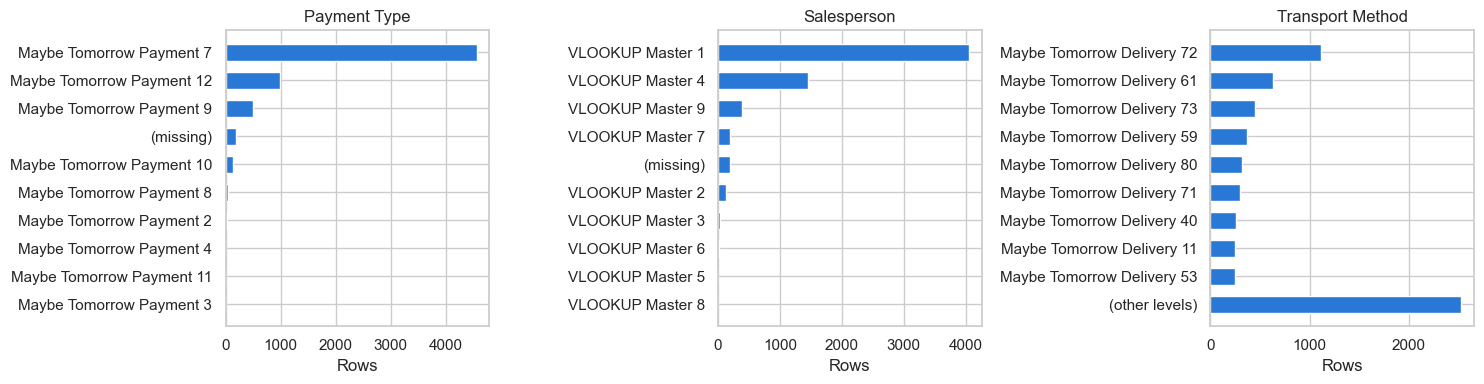

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["payment_type", "salesperson", "transport_method"]):
    vc = tr[col].fillna("(missing)").value_counts()
    vc = pd.concat([vc.head(9), pd.Series({"(other levels)": vc.iloc[9:].sum()})]) if len(vc) > 10 else vc
    vc = vc[vc > 0]
    ax.barh(vc.index[::-1], vc.values[::-1], color=BLUE, height=0.6)
    ax.set(title=nice(col), xlabel="Rows")
plt.tight_layout(); plt.show()

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>On a log scale Total Payable, Prior Total Spend and Spend 365 Days are roughly bell shaped, so a log transform suits them in Task 2. The history counts, Prior Total Spend and the window counts have a separate spike at zero for first purchases or empty windows, which forms its own group rather than the low end of a continuum. Days Since Previous Purchase peaks at about two weeks and again at about 100 days, which suggests regular ordering cycles. Random Noise is a symmetric bell around zero. Payment Type and Salesperson are each led by one level (Payment 7 with 4,565 rows, Master 1 with 4,054), and Transport Method has a long tail of rare levels.</p>

</div>

<a id="bi"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>8. Bivariate relationships with the target</h2>

<h3>8.1 Numeric features: one-feature ranking power</h3>

<p>For each numeric feature we compute the ROC AUC of its raw value against the target. An AUC of 0.5 means no signal; values below 0.5 mean that higher values go with fewer repeat purchases. Because AUC only uses the ranking of the values, it is unaffected by skew and scale. Missing rows are left out, and placeholder codes are removed first.</p>

</div>

In [88]:
rows = []
for col in NUMERIC + ["random_noise"]:
    m = h[col].notna()
    auc = roc_auc_score(h.loc[m, TARGET], h.loc[m, col])
    med1 = h.loc[m & (h[TARGET] == 1), col].median()
    med0 = h.loc[m & (h[TARGET] == 0), col].median()
    rows.append({"Feature": nice(col), "Role": role(col), "AUC": auc, "Distance from 0.5": abs(auc - 0.5),
                 "Median if Repeat": med1, "Median if No Repeat": med0})
auc_table = pd.DataFrame(rows).set_index("Feature").sort_values("Distance from 0.5", ascending=False)
auc_table

,Role,AUC,Distance from 0.5,Median if Repeat,Median if No Repeat
Feature,,,,,
Purchase Count 365 Days,rolling window,0.753,0.253,5.000,2.000
Prior Mean Gap Days,customer history,0.254,0.246,55.500,101.265
Purchase Count 180 Days,rolling window,0.732,0.232,3.000,1.000
Spend 365 Days,rolling window,0.725,0.225,"4,544.380","1,150.160"
Purchase Count 90 Days,rolling window,0.716,0.216,1.000,0.000
Spend 180 Days,rolling window,0.714,0.214,"2,106.220",457.870
Prior Purchase Count,customer history,0.701,0.201,17.000,6.000
Spend 90 Days,rolling window,0.699,0.199,746.190,0.000
Prior Total Spend,customer history,0.693,0.193,"12,098.990","3,246.525"


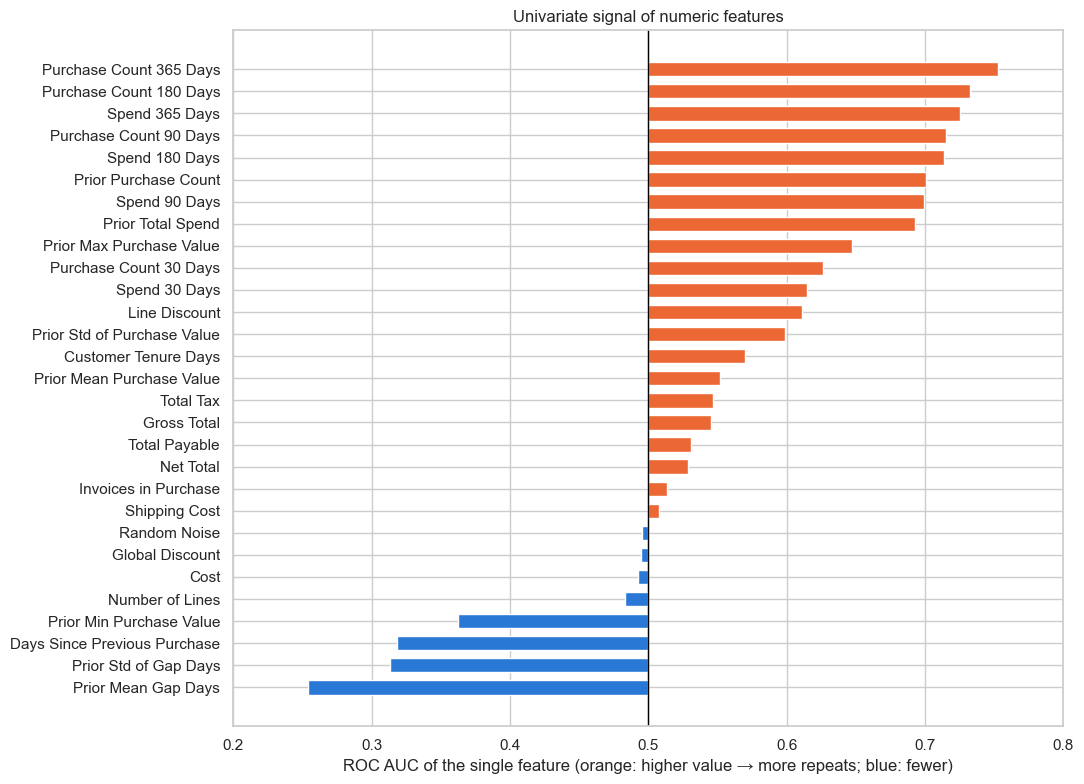

In [89]:
fig, ax = plt.subplots(figsize=(11, 8))
a = auc_table.sort_values("AUC")
colors = [ORANGE if v > 0.5 else BLUE for v in a["AUC"]]
ax.barh(a.index, a["AUC"] - 0.5, left=0.5, color=colors, height=0.65)
ax.axvline(0.5, color="black", lw=1)
ax.set(xlabel="ROC AUC of the single feature (orange: higher value → more repeats; blue: fewer)",
       title="Univariate signal of numeric features", xlim=(0.2, 0.8))
plt.tight_layout(); plt.show()

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>Purchase behaviour predicts the target, while the current invoice barely does. Purchase Count 365 Days alone reaches an AUC of 0.753, followed by the 180 and 90 day counts (0.732 and 0.716), Spend 365 Days (0.725) and Prior Purchase Count (0.701), and repeating customers had a median of 5 purchases in the past year against 2. A short average gap between earlier purchases (Prior Mean Gap Days, AUC 0.254, median 55.5 against 101.3 days) and a recent previous purchase (Days Since Previous Purchase, AUC 0.318, median 37 against 105 days) also raise the chance of a repeat. The invoice columns lie between 0.48 and 0.55, and only Line Discount stands out a little at 0.611. This is the classic recency, frequency and monetary pattern.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>8.2 The shape of the strongest relationships</h3>

<p>The plots show the repeat rate within bins of the three behavioural dimensions: <b>recency</b>, <b>frequency</b> and <b>customer tenure</b>. The number of rows in each bin is printed along the bottom, so that a high rate in a bin with only a few rows is not over-interpreted. The dashed line marks the overall repeat rate.</p>

</div>

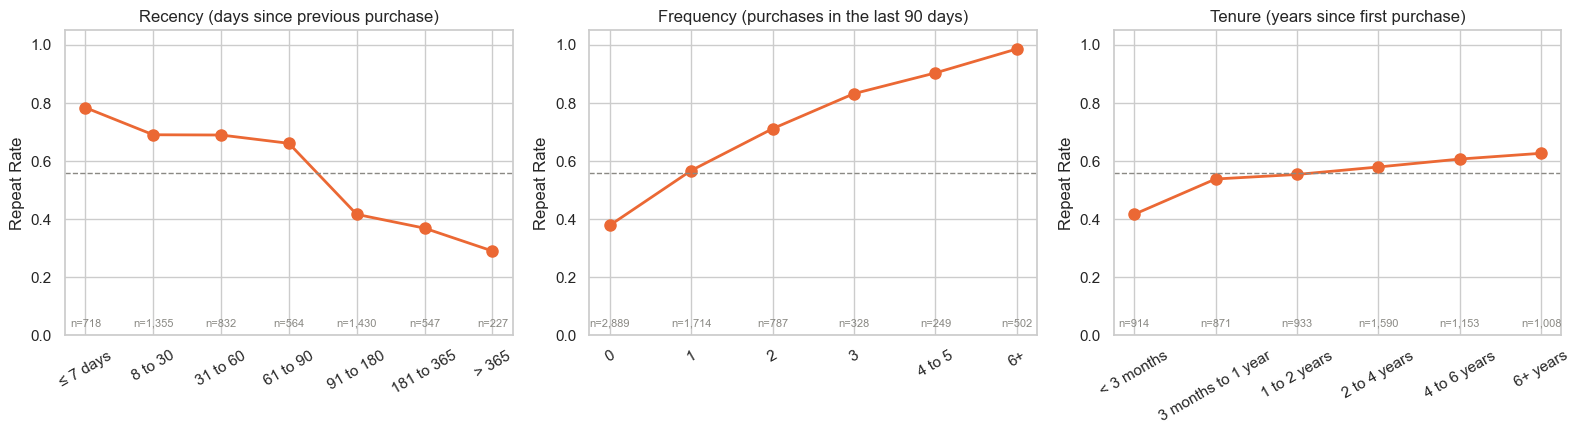

In [90]:
def rate_by_bin(ax, series, bins, labels, title):
    b = pd.cut(series, bins=bins, labels=labels)
    g = h.groupby(b, observed=True)[TARGET].agg(["mean", "size"])
    ax.plot(range(len(g)), g["mean"], marker="o", color=ORANGE, lw=2, ms=8)
    for i, n in enumerate(g["size"]):
        ax.text(i, 0.03, f"n={n:,}", ha="center", fontsize=8, color=GREY)
    ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, rotation=30)
    ax.set(ylim=(0, 1.05), ylabel="Repeat Rate", title=title)
    ax.axhline(h[TARGET].mean(), color=GREY, ls="--", lw=1)
    return g

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
g_rec = rate_by_bin(axes[0], h["days_since_previous_purchase"], [-10, 7, 30, 60, 90, 180, 365, 5000],
                    ["≤ 7 days", "8 to 30", "31 to 60", "61 to 90", "91 to 180", "181 to 365", "> 365"],
                    "Recency (days since previous purchase)")
g_frq = rate_by_bin(axes[1], h["purchase_count_90d"], [-1, 0, 1, 2, 3, 5, 100],
                    ["0", "1", "2", "3", "4 to 5", "6+"], "Frequency (purchases in the last 90 days)")
g_ten = rate_by_bin(axes[2], h["customer_tenure_days"] / 365.25, [-0.01, 0.25, 1, 2, 4, 6, 10],
                    ["< 3 months", "3 months to 1 year", "1 to 2 years", "2 to 4 years", "4 to 6 years", "6+ years"],
                    "Tenure (years since first purchase)")
plt.tight_layout(); plt.show()

bins_table = (pd.concat({"Recency": g_rec, "Frequency (90 Days)": g_frq, "Tenure": g_ten})
                .rename(columns={"mean": "Repeat Rate", "size": "Purchases"})
                .rename_axis(["Dimension", "Group"]))
display(bins_table.style
        .format({"Repeat Rate": "{:.1%}", "Purchases": "{:,}"})
        .set_caption("Repeat rate by recency, frequency and tenure")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{"selector": "", "props": "margin-left:auto; margin-right:auto;"},
                           {"selector": "th", "props": "text-align:center;"}]))

In [91]:
# First-time buyers are a distinct group: no history at all.
first = h["prior_purchase_count"] == 0
print(f"First purchases: {first.sum()} rows, repeat rate {h.loc[first, TARGET].mean():.3f} "
      f"vs {h.loc[~first, TARGET].mean():.3f} for returning customers")

First purchases: 603 rows, repeat rate 0.333 vs 0.583 for returning customers


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>All three relationships are monotonic. The repeat rate is 0.78 when the previous purchase was at most a week ago, stays at 0.66 to 0.69 up to 90 days and then drops to 0.42 for 91 to 180 days and 0.29 beyond a year. This drop at 90 days matches the 90 day definition of the target. With purchases in the last 90 days the rate rises from 0.38 for none to 0.99 for six or more (502 rows). Tenure has a weaker effect, from 0.42 in the first three months to 0.63 after six years. First purchases repeat at only 0.333 against 0.583 for returning customers, so a newly acquired customer is the least likely to come back.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>8.3 Categorical features</h3>

<p>For each categorical feature we show the repeat rate per level (only levels with at least 30 rows). A chi-square test checks whether the feature and the target are independent, and Cramér's V measures how strong the relationship is (0 = none, 1 = perfect). Missing values are kept as their own level.</p>

</div>

In [92]:
rows = []
for col in CATEGORICAL:
    tab = pd.crosstab(tr[col].fillna("(missing)"), tr[TARGET])
    chi2, p, dof, _ = chi2_contingency(tab)
    v = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
    rows.append({"Feature": nice(col), "Levels (incl. Missing)": tab.shape[0], "Chi2": chi2, "P Value": p, "Cramér's V": v})
pd.DataFrame(rows).set_index("Feature").sort_values("Cramér's V", ascending=False)

,Levels (incl. Missing),Chi2,P Value,Cramér's V
Feature,,,,
Transport Method,81,527.225,0.000,0.285
Payment Type,10,354.353,0.000,0.234
Salesperson,10,260.760,0.000,0.201
Commercial Zone,5,26.295,0.000,0.064
Warehouse,3,10.167,0.006,0.040
Document Series,3,0.055,0.973,0.003


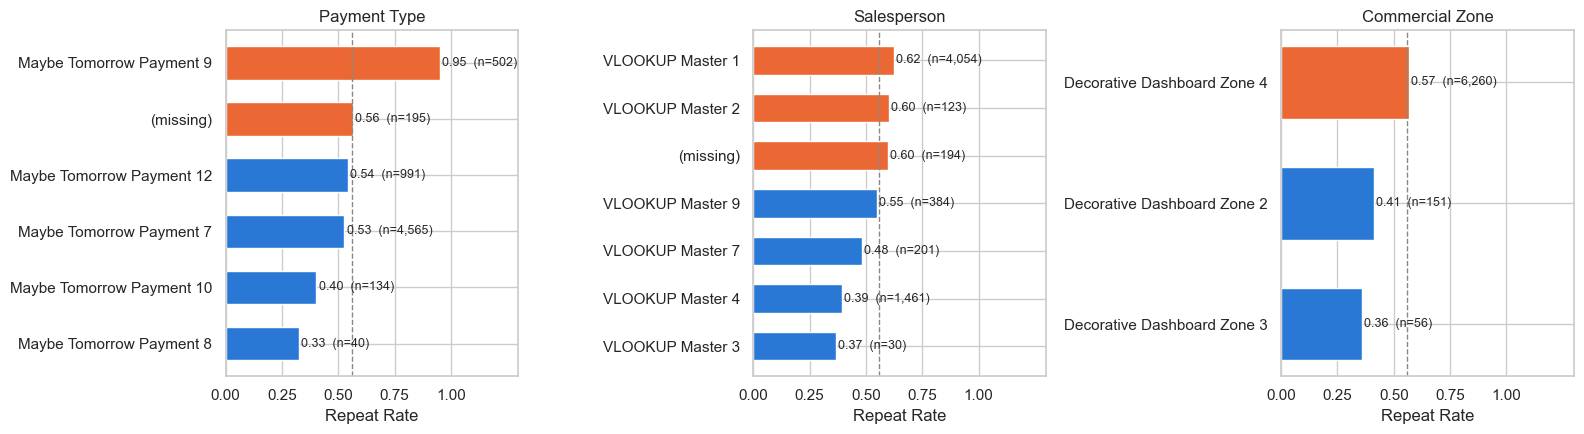

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["payment_type", "salesperson", "commercial_zone"]):
    t = rate_table(tr, col)
    ax.barh(t.index, t["mean"], color=[ORANGE if m > tr[TARGET].mean() else BLUE for m in t["mean"]], height=0.6)
    for i, (m, n) in enumerate(zip(t["mean"], t["size"])):
        ax.text(m + 0.01, i, f"{m:.2f}  (n={n:,})", va="center", fontsize=9)
    ax.axvline(tr[TARGET].mean(), color=GREY, ls="--", lw=1)
    ax.set(xlim=(0, 1.3), xticks=[0, 0.25, 0.5, 0.75, 1], xlabel="Repeat Rate", title=nice(col))
plt.tight_layout(); plt.show()

In [94]:
pt = tr["payment_type"].where(tr["payment_type"].isin(["Maybe Tomorrow Payment 7", "Maybe Tomorrow Payment 9",
                                                      "Maybe Tomorrow Payment 12"]), "Other or Missing")
freq = pd.cut(tr["purchase_count_90d"], [-1, 0, 2, 100], labels=["0", "1 to 2", "3+"]).astype(object)

(pd.crosstab(pt, freq, values=tr[TARGET], aggfunc="mean").round(3)
   .join(pd.crosstab(pt, freq).add_prefix("Rows "))
   .rename_axis(index="Payment Type", columns="Purchase Count 90 Days"))

Purchase Count 90 Days,0,1 to 2,3+,Rows 0,Rows 1 to 2,Rows 3+
Payment Type,,,,,,
Maybe Tomorrow Payment 12,0.343,0.569,0.931,461,313,217
Maybe Tomorrow Payment 7,0.385,0.619,0.847,2188,1965,412
Maybe Tomorrow Payment 9,0.478,0.852,0.990,23,61,418
Other or Missing,0.387,0.537,0.875,217,162,32


In [95]:
# Calendar effects
show_rates(rate_table(tr.assign(weekday=tr["purchase_date"].dt.day_name()), "weekday", 1), "Weekday")

,Repeat Rate,Rows
Weekday,,
Saturday,0.501,3215
Wednesday,0.548,84
Sunday,0.560,1022
Thursday,0.625,24
Tuesday,0.631,683
Friday,0.644,811
Monday,0.671,630


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>Payment Type (Cram&eacute;r's V 0.234) and Salesperson (0.201) are related to the target, partly through customer behaviour. Payment 9 repeats at 0.95 against 0.53 for the dominant Payment 7, but 418 of its 502 rows belong to customers with three or more recent purchases, so it largely marks very active customers. At equal frequency it still stays higher (0.852 against 0.619 at one to two recent purchases). Master 1 repeats at 0.62 and Master 4 at 0.39 on 1,461 rows, which likely reflects the customers each one serves. Transport Method has the highest V (0.285), but with 81 levels including missing and many tiny cells this value is inflated until rare levels are grouped. Commercial Zone and Warehouse are weak and Document Series shows no relation at all (p = 0.97). Saturday has the lowest rate (0.50 on 3,215 rows) and Monday the highest (0.67), which may reflect the type of customer more than the day itself.</p>

</div>

<a id="multi"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>9. Multivariate relationships</h2>

<h3>9.1 Correlation structure</h3>

<p>We use Spearman (rank) correlation instead of Pearson, because nearly every column is skewed and contains outliers. Spearman only compares the ranking of the values, so a few extreme values cannot dominate the result.</p>

</div>

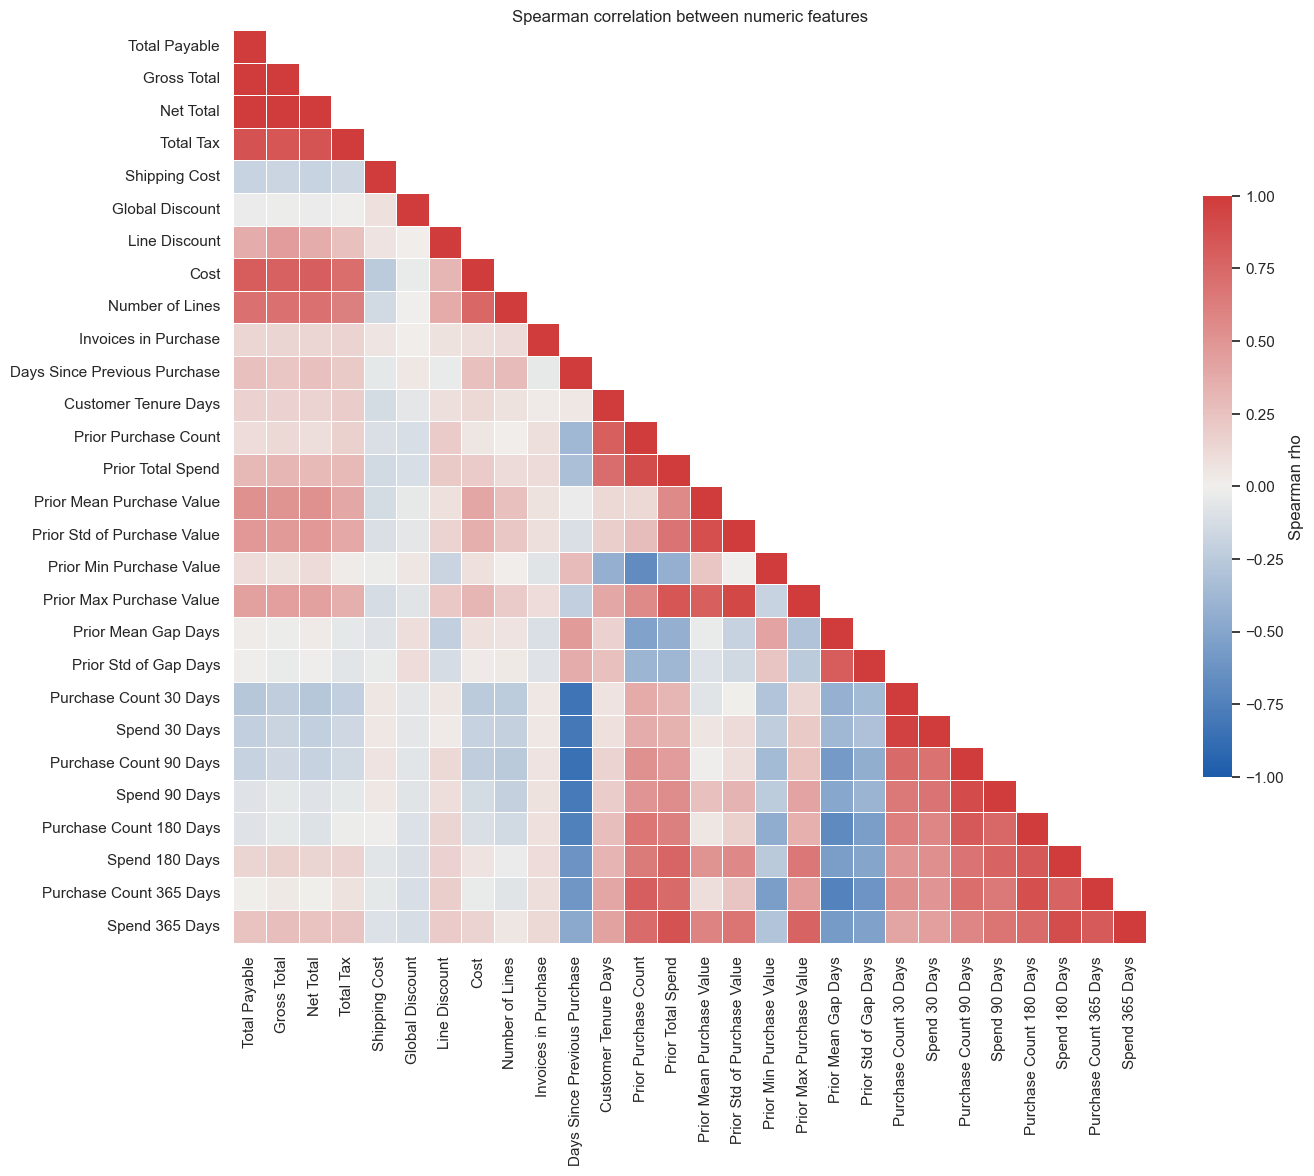

,,Spearman Rho
Feature A,Feature B,
Total Payable,Net Total,1.000
Gross Total,Net Total,0.991
Total Payable,Gross Total,0.991
Purchase Count 30 Days,Spend 30 Days,0.965
Prior Std of Purchase Value,Prior Max Purchase Value,0.923
Purchase Count 90 Days,Spend 90 Days,0.909
Prior Purchase Count,Prior Total Spend,0.903
Spend 180 Days,Spend 365 Days,0.894
Purchase Count 180 Days,Purchase Count 365 Days,0.888


In [96]:
corr_cols = INVOICE + HISTORY + WINDOWS
corr = h[corr_cols].corr(method="spearman").rename(index=nice, columns=nice)
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap=DIVERGING, vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.6, "label": "Spearman rho"}, ax=ax)
ax.set_title("Spearman correlation between numeric features"); ax.grid(False)
plt.tight_layout(); plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
display(pairs[pairs.abs() >= 0.85].sort_values(ascending=False).round(3)
        .rename("Spearman Rho").rename_axis(["Feature A", "Feature B"]).to_frame())

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>The numeric features form a few highly redundant clusters. Total Payable, Net Total and Gross Total are practically the same variable (&rho; 0.99 to 1.00) and Total Tax follows closely (0.86 to 0.87). Count and spend of the same window move together (0.965 for 30 days, 0.909 for 90 days), as do the 180 and 365 day windows (0.89) and lifetime count and spend (0.903). Days Since Previous Purchase and Purchase Count 90 Days are strongly negatively correlated (&rho; = &minus;0.853), so they measure the same thing from two sides. The invoice block and the behaviour block are nearly uncorrelated, which matches Section 8. Many features can therefore be removed in Task 3 with little loss, and linear models need correlation filtering or regularisation.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>9.2 Recency and frequency together</h3>

</div>

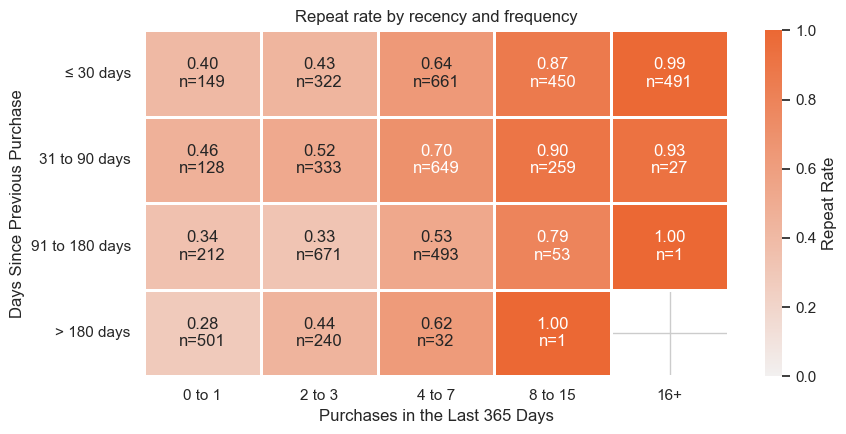

In [97]:
rec = pd.cut(h["days_since_previous_purchase"], [-10, 30, 90, 180, 5000],
             labels=["≤ 30 days", "31 to 90 days", "91 to 180 days", "> 180 days"])
frq = pd.cut(h["purchase_count_365d"], [-1, 1, 3, 7, 15, 100], labels=["0 to 1", "2 to 3", "4 to 7", "8 to 15", "16+"])
grid = h.groupby([rec, frq], observed=False)[TARGET].agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(9, 4.5))
annot = grid.apply(lambda r: f"{r['mean']:.2f}\nn={int(r['size'])}" if r["size"] > 0 else "", axis=1).unstack()
sns.heatmap(grid["mean"].unstack(), annot=annot, fmt="", cmap=sns.light_palette(ORANGE, as_cmap=True),
            vmin=0, vmax=1, linewidths=1, linecolor="white", cbar_kws={"label": "Repeat Rate"}, ax=ax)
ax.set(xlabel="Purchases in the Last 365 Days", ylabel="Days Since Previous Purchase",
       title="Repeat rate by recency and frequency")
plt.tight_layout(); plt.show()

In [98]:
# Does the value of the current purchase add anything once frequency is known?
value_q = pd.qcut(h["Total a Pagar"], 4, labels=["Q1 (small)", "Q2", "Q3", "Q4 (large)"])
freq3 = pd.cut(h["purchase_count_365d"], [-1, 3, 10, 100], labels=["0 to 3", "4 to 10", "11+"])
(pd.crosstab(value_q, freq3, values=h[TARGET], aggfunc="mean").round(3)
   .rename_axis(index="Total Payable Quartile", columns="Purchase Count 365 Days"))

Purchase Count 365 Days,0 to 3,4 to 10,11+
Total Payable Quartile,,,
Q1 (small),0.350,0.618,0.961
Q2,0.320,0.653,0.979
Q3,0.371,0.674,0.969
Q4 (large),0.461,0.727,0.950


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>Frequency dominates, within each recency band the repeat rate rises strongly with yearly frequency, for example from 0.40 to 0.99 when the previous purchase was within 30 days. Within a frequency band recency moves the rate much less and not monotonically (0.43, 0.52, 0.33 and 0.44 across the four recency bands for two to three purchases a year), so much of the recency effect in Section 8.2 is frequency seen from the other side. Some combinations hardly occur, such as 16 or more purchases a year with the last one more than 90 days ago. The value of the current purchase matters only for infrequent customers, where the largest quarter repeats at 0.46 against 0.32 to 0.37. The effect is smaller for 4 to 10 purchases (0.62 to 0.73) and disappears for 11 or more (0.95 to 0.98), which a tree model can use but a purely additive model cannot.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>9.3 Customers as clusters of rows</h3>

</div>

Customers with at least one row with data: 607 of 610 (3 customers have only empty rows)
Customers with more than one row: 450; of these, with both outcomes: 77.3%
Customers with a single row: 157, their mean repeat rate: 0.000
Between customer share of target variance: 35.0%


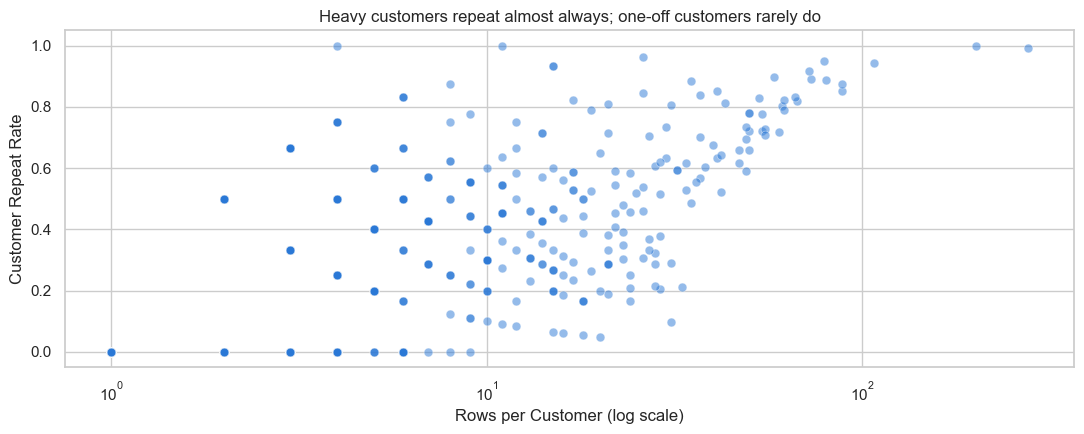

In [99]:
cust = tr.groupby("customer_id")[TARGET].agg(["mean", "size"])
multi = cust[cust["size"] > 1]
print(f"Customers with at least one row with data: {len(cust)} of {train['customer_id'].nunique()} "
      f"({train['customer_id'].nunique() - len(cust)} customers have only empty rows)")
print(f"Customers with more than one row: {len(multi)}; of these, with both outcomes: "
      f"{((multi['mean'] > 0) & (multi['mean'] < 1)).mean():.1%}")
print(f"Customers with a single row: {(cust['size'] == 1).sum()}, their mean repeat rate: "
      f"{cust.loc[cust['size'] == 1, 'mean'].mean():.3f}")
# Share of target variance explained by the customer alone (between-customer variance)
grand = tr[TARGET].mean()
between = (cust["size"] * (cust["mean"] - grand) ** 2).sum() / len(tr)
print(f"Between customer share of target variance: {between / tr[TARGET].var(ddof=0):.1%}")
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.scatterplot(x=cust["size"], y=cust["mean"], color=BLUE, alpha=0.5, s=40, ax=ax, edgecolor="white")
ax.set(xscale="log", xlabel="Rows per Customer (log scale)", ylabel="Customer Repeat Rate",
       title="Heavy customers repeat almost always; one-off customers rarely do")
plt.tight_layout(); plt.show()

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>Much of the target is a property of the customer. After removing the empty rows 607 customers remain, because 3 of the 610 customers have only empty rows, and 450 of them have more than one row. 77.3% of these show both outcomes, so the label is not fixed per customer. Still, 35% of the target variance lies between customers, and all 157 customers with a single row have a repeat rate of 0, which is almost a tautology since a customer who bought again soon would have produced another row. A random split would leak customer identity into validation, so Task 4 should use GroupKFold by customer or a time based split.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>9.4 How the target relates to the customer's next row</h3>

<p>The target Repeat Purchase 90 Days is defined by future behaviour. Because train holds the customer's consecutive purchases, the next purchase of the same customer is often in the file. The check below compares the target with the gap to the customer's next row in train. This is an <b>exploration of how the label was built</b>, not a feature: a column computed from later rows would not be available at the moment of a real prediction.</p>

</div>

In [100]:
seq = tr.sort_values(["customer_id", "purchase_date"]).copy()
grp = seq.groupby("customer_id")["purchase_date"]
seq["days_to_next_row"] = (grp.shift(-1) - seq["purchase_date"]).dt.days
seq["days_from_prev_row"] = (seq["purchase_date"] - grp.shift(1)).dt.days
seq["next_within_90"] = np.where(seq["days_to_next_row"].isna(), "No Next Row",
                                 np.where(seq["days_to_next_row"] <= 90, "Yes", "No"))
display(pd.crosstab(seq["next_within_90"], seq[TARGET], margins=True, margins_name="Total")
        .rename_axis(index="Next Row within 90 Days", columns=nice(TARGET)))
reconstructed = (seq["days_to_next_row"] <= 90).astype(int)
mismatch = reconstructed != seq[TARGET]
last = seq["days_to_next_row"].isna()
print(f"Agreement of 'next row within 90 days' with the target: {(~mismatch).mean():.2%}")
print(f"Exceptions: {mismatch.sum()}, of which on a customer's last row: {(mismatch & last).sum()} "
      f"({(mismatch & last & (seq['purchase_date'].dt.year == 2025)).sum()} of them in 2025)")
print("Repeat rate of each customer's last train row, by year:",
      seq.loc[last].groupby(seq.loc[last, "purchase_date"].dt.year)[TARGET].mean().round(2).to_dict())
print(f"Days Since Previous Purchase equals the gap to the previous train row in "
      f"{(seq['days_from_prev_row'] == seq['days_since_previous_purchase']).mean():.1%} of rows")

Repeat Purchase 90 Days,0,1,Total
Next Row within 90 Days,,,
No,2282,15,2297
No Next Row,566,41,607
Yes,0,3565,3565
Total,2848,3621,6469


Agreement of 'next row within 90 days' with the target: 99.13%
Exceptions: 56, of which on a customer's last row: 41 (33 of them in 2025)
Repeat rate of each customer's last train row, by year: {2015: 0.0, 2016: 0.0, 2017: 0.02, 2018: 0.0, 2019: 0.0, 2020: 0.0, 2021: 0.0, 2022: 0.0, 2023: 0.0, 2024: 0.05, 2025: 0.53}
Days Since Previous Purchase equals the gap to the previous train row in 86.6% of rows


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>The target is almost exactly the rule that the customer's next row in train comes within 90 days, which holds on 99.1% of rows. All 3,565 rows with a next row within 90 days are labelled 1, and 2,282 of the 2,297 rows with a later next row are labelled 0. Of the 56 exceptions, 41 are a customer's last row in train, mostly from 2025 (33), where the next purchase falls after the end of the file in February 2025. The rest come from purchases missing in the file, since Days Since Previous Purchase matches the gap to the previous train row on only 86.6% of rows. The target is therefore well defined, but any feature built from a customer's later rows would be target leakage, so features must only use information up to the purchase date, and validation should be grouped or time based.</p>

</div>

<a id="shift"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>10. Stability over time within train</h2>

<p>Train spans almost ten years. If the customer population or the coding of the variables changed over that period, a model fitted on older rows may not hold for later ones. This section compares the periods inside train.</p>

</div>

In [101]:
period = pd.cut(tr["purchase_date"].dt.year, [2014, 2018, 2021, 2025],
                labels=["2015 to 2018", "2019 to 2021", "2022 to 2025"])
cmp_cols = ["customer_tenure_days", "prior_purchase_count", "prior_total_spend", "days_since_previous_purchase",
            "purchase_count_90d", "purchase_count_365d", "Total a Pagar", "N_ Detalhes"]
medians = h[cmp_cols].groupby(period, observed=True).median().T.rename(index=nice)
pd.concat([medians,
           tr.groupby(period, observed=True)[TARGET].mean().to_frame("Repeat Rate").T,
           period.value_counts().sort_index().to_frame("Rows").T]).rename_axis(index="Median by Period", columns=None)

,2015 to 2018,2019 to 2021,2022 to 2025
Median by Period,,,
Customer Tenure Days,309.000,"1,119.000","1,918.000"
Prior Purchase Count,4.000,14.000,20.000
Prior Total Spend,"2,275.790","8,205.470","14,094.630"
Days Since Previous Purchase,49.000,57.000,64.000
Purchase Count 90 Days,1.000,1.000,1.000
Purchase Count 365 Days,3.000,4.000,4.000
Total Payable,382.060,450.070,620.285
Number of Lines,9.000,10.000,15.000
Repeat Rate,0.562,0.555,0.562


In [102]:
display(pd.crosstab(tr["purchase_date"].dt.year, tr["document_series"])
        .rename_axis(index="Year", columns="Document Series"))
for col in ["salesperson", "payment_type", "commercial_zone"]:
    t = pd.crosstab(tr[col], period, normalize="columns").round(3)
    display(t[t.max(axis=1) >= 0.01].rename_axis(index=nice(col), columns="Share by Period (levels with ≥ 1% of rows)"))

Document Series,Ctrl Z Series 1,Ctrl Z Series 2,Ctrl Z Series 3
Year,,,
2015,0,0,335
2016,0,0,420
2017,281,0,389
2018,387,0,329
2019,397,0,249
2020,532,0,138
2021,231,508,43
2022,0,628,0
2023,0,767,0


Share by Period (levels with ≥ 1% of rows),2015 to 2018,2019 to 2021,2022 to 2025
Salesperson,,,
VLOOKUP Master 1,0.754,0.645,0.544
VLOOKUP Master 2,0.059,0.000,0.000
VLOOKUP Master 3,0.014,0.000,0.000
VLOOKUP Master 4,0.080,0.341,0.277
VLOOKUP Master 7,0.090,0.007,0.000
VLOOKUP Master 9,0.000,0.000,0.177


Share by Period (levels with ≥ 1% of rows),2015 to 2018,2019 to 2021,2022 to 2025
Payment Type,,,
Maybe Tomorrow Payment 10,0.000,0.020,0.044
Maybe Tomorrow Payment 12,0.186,0.138,0.150
Maybe Tomorrow Payment 2,0.000,0.000,0.010
Maybe Tomorrow Payment 7,0.791,0.704,0.689
Maybe Tomorrow Payment 8,0.000,0.006,0.013
Maybe Tomorrow Payment 9,0.023,0.133,0.086


Share by Period (levels with ≥ 1% of rows),2015 to 2018,2019 to 2021,2022 to 2025
Commercial Zone,,,
Decorative Dashboard Zone 2,0.000,0.016,0.052
Decorative Dashboard Zone 3,0.003,0.010,0.013
Decorative Dashboard Zone 4,0.997,0.973,0.935


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>The repeat rate is stable at 0.562, 0.555 and 0.562 across the three periods, each with 2,098 to 2,230 rows. Lifetime features drift upwards by construction, with median tenure growing from 309 to 1,918 days, lifetime purchases from 4 to 20 and lifetime spend from 2,276 to 14,095, simply because the data starts in 2015 and early rows cannot have a long history. Recent behaviour is far more stable (Purchase Count 365 Days 3, 4 and 4, recency 49, 57 and 64 days), so it should generalise better. Document Series works like a clock, with Series 3 running from 2015 to 2021, Series 1 from 2017 to 2021 and Series 2 only from 2021, and together with its missing link to the target it should be dropped. Category levels appear and disappear, since Master 9 only exists from 2022 (17.7% of recent rows), Masters 2 and 3 only before 2019 and Master 7 almost vanishes after 2018, so encoders must handle unseen levels. Median Total Payable also rises from 382 to 620, partly through price development.</p>

</div>

<a id="summary"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>11. Summary of insights and implications for Task 2</h2>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>What the data is</h3>

<p>Train holds 6,534 purchases from 610 customers between July 2015 and February 2025, and test.csv is held back for the final evaluation. The target Repeat Purchase 90 Days is positive on 55.9% of rows, which gives a majority baseline accuracy of 0.559, and it is stable over time. The features form five blocks (current invoice, customer history, rolling windows, categorical codes, identifiers and noise), and the customer table adds static attributes that are mostly sparse or identifier like.</p>

<h3>Key insights</h3>

<p>Purchase behaviour drives repeat purchases. Frequency (Purchase Count 365 Days, AUC 0.75), regularity (Prior Mean Gap Days) and recency (Days Since Previous Purchase) dominate, the repeat rate falls sharply once the previous purchase is more than 90 days ago, and it rises to 0.99 for customers with six or more purchases in 90 days, while the current invoice carries almost no signal. First purchases form a distinct group of 603 rows with a repeat rate of 0.33. Payment Type (Payment 9 at 0.95) and Salesperson matter, partly as markers of very active customers. Two invoice columns are exact combinations of others, and amounts, counts and window features form highly correlated clusters. The label equals "next purchase within 90 days" on 99.1% of rows, so features from later rows would leak the target. Rows are clustered by customer (35% of the target variance lies between customers), and lifetime features and category levels drift over time while recent behaviour stays stable.</p>

<h3>Data quality issues and decisions for Task 2</h3>
<table>
  <tr><th>#</th><th>Issue</th><th>Extent</th><th>Proposed Handling (to be justified in Task 2)</th></tr>
  <tr><td>1</td><td>Completely empty rows</td><td>65 rows</td><td>Drop</td></tr>
  <tr><td>2</td><td>Structural missing history (first or second purchase)</td><td>603 / 445 / 365 rows</td><td>Indicator plus neutral fill, not median imputation</td></tr>
  <tr><td>3</td><td>Values missing at random in history and 4 categorical variables</td><td>About 3% per column</td><td>Impute (median, mode or a missing level), fitted on train only</td></tr>
  <tr><td>4</td><td>Placeholder 1e9, negative amounts, &minus;4 days</td><td>94 rows</td><td>Set to missing, then recompute from consistent columns or impute</td></tr>
  <tr><td>5</td><td>Remaining inconsistent history values</td><td>39 to 46 rows per rule</td><td>Recompute Prior Mean Purchase Value as total / count, set inflated Prior Max Purchase Value and Spend 365 Days to missing and impute</td></tr>
  <tr><td>6</td><td>Exact identities in invoice amounts</td><td>2 redundant columns</td><td>Keep one representation</td></tr>
  <tr><td>7</td><td>Heavy right skew, many zeros</td><td>Most amount columns</td><td>Log transform, zero indicators where useful</td></tr>
  <tr><td>8</td><td>Rare, retired and new category levels</td><td>Transport Method with 80 levels, Salesperson levels change over time</td><td>Group rare levels, use an encoder that ignores unknown levels</td></tr>
  <tr><td>9</td><td>Identifier like and noise columns</td><td>ID, Customer ID, Random Noise, Document Series</td><td>Exclude from features (ID kept as row key, Customer ID for joins and grouping)</td></tr>
  <tr><td>10</td><td>Customer table</td><td>Complete coverage, mostly sparse</td><td>Join, try Country or Region and an Island Known flag, drop identifiers and Customer Type</td></tr>
</table>

<h3>Implications for modelling</h3>

<p>Validation within train should be grouped by customer or time based, never a plain random split. The metric should be robust to the 56 to 44 class split, with ROC AUC as the main measure plus F1 or balanced accuracy, and it should always be compared with the 0.559 majority baseline.</p>

</div>